# Nexus Sentinel
## Detección de uso indebido de credenciales con analítica de comportamiento

La mayoría de las brechas de seguridad modernas no rompen nada. Usan credenciales legítimas
—robadas, compradas o abusadas por alguien de dentro— para moverse por la red como un usuario más.
Cada autenticación es técnicamente válida, así que ninguna regla se dispara. Este notebook documenta
cómo construí un sistema que detecta ese comportamiento, de principio a fin: desde mil millones de
eventos crudos hasta una interfaz desplegada en producción.

La idea que gobierna todo el trabajo se resume en una frase: **el modelo no ve eventos, ve
desviaciones**. Para cada usuario construyo una línea base de comportamiento y mido, día a día,
cuánto se aleja de ella.

**Cómo ejecutarlo.** El notebook está pensado para correr de arriba a abajo en Google Colab sin
intervención. Los datos pesados se descargan automáticamente y los artefactos ya entrenados vienen
en el repositorio, así que no hace falta reentrenar nada para reproducir los resultados.

**El recorrido:** los datos y su muestreo · análisis exploratorio · ingeniería de variables ·
modelado y evaluación · inferencia y puntuación de riesgo · la API que consume la interfaz ·
conclusiones.

### Preparación del entorno

Empiezo dejando el entorno listo. En Colab hay que clonar el repositorio e instalar dependencias
(las tres primeras líneas, comentadas); en local basta con añadir la raíz del proyecto al path,
porque el notebook vive en `notebook/` y los módulos en `src/`.

También silencio los avisos de las librerías. No es por esconder problemas: son advertencias de
compatibilidad entre versiones de pandas, sklearn y shap que no afectan a los resultados, y que
ensucian la lectura de un notebook cuyo propósito es comunicar.

In [1]:
# En Colab, descomenta estas tres lineas para clonar el proyecto e instalar dependencias:
# !git clone https://github.com/AAO-dev/nexus-sentinel.git
# %cd nexus-sentinel/notebook
# !pip install -q -r ../requirements.txt

import logging
import os
import sys
import warnings

# El notebook vive en notebook/ y los modulos del proyecto en src/
sys.path.insert(0, '..')

# Silencia los avisos de compatibilidad entre versiones de pandas, scikit-learn y shap.
# No afectan a los resultados y ensucian la lectura de las salidas.
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'
logging.getLogger('shap').setLevel(logging.ERROR)

from src import data, eda

## 1. Los datos: de mil millones de eventos a una muestra manejable

Trabajo con registros **reales** de autenticación de la red corporativa interna del Laboratorio
Nacional de Los Álamos, publicados por Kent (2015). Son 58 días consecutivos de eventos
desidentificados, y lo que los hace especialmente valiosos es que incluyen los ataques de un equipo
de *red team* profesional, etiquetados: tengo verdad de terreno sobre comportamiento malicioso real.

El conjunto completo documenta 1,648,275,307 eventos de 12,425 usuarios y 17,684 computadoras. De
sus cinco fuentes uso dos: `auth.txt.gz` (7.2 GB comprimidos, unos 1,051 millones de autenticaciones
Windows/Active Directory) y `redteam.txt.gz` (4.8 KB, los eventos de compromiso que sirven de
etiquetas).

Elegí esta fuente precisamente porque reproduce las condiciones que un científico de datos encuentra
en un centro de operaciones de seguridad real: desbalance extremo, volumen masivo y datos
desidentificados por privacidad.

### La ruta larga: regenerar todo desde la fuente

Esta celda reproduce la adquisición completa. Vale la pena explicar un obstáculo que encontré aquí,
porque cambió el diseño del módulo: la documentación y los trabajos previos sobre este conjunto
asumen una descarga directa y anónima, pero el portal de LANL ahora antepone un *data fence* —un
formulario que pide correo y declaración de uso, y devuelve un token temporal con el que se arma la
URL—. Tuve que adaptar el código para solicitar ese token programáticamente antes de poder descargar.

El segundo obstáculo fue el volumen. Descargar 7.2 GB y procesarlos exigía cuidado: implementé la
descarga en *streaming* con reanudación automática (que efectivamente tuvo que reanudarse tras una
interrupción a mitad de la transferencia) y la lectura del archivo comprimido por bloques, sin
descomprimirlo nunca por completo a disco.

Tarda entre una y dos horas, así que la dejo desactivada por defecto. La ruta rápida viene después.

In [2]:
REGENERATE = False

if REGENERATE:
    EMAIL = ''   # requerido por el data fence de LANL
    USAGE = 'Academic data science course project: user behavior analytics / anomaly detection research'
    token = data.request_download_token(EMAIL, USAGE)
    for fname in ('redteam.txt.gz', 'auth.txt.gz'):
        data.download_streaming(fname, '../data/raw', token)
    meta = data.build_working_sample('../data/raw/auth.txt.gz', '../data/raw/redteam.txt.gz',
                                     out_dir='../data/work')
    print(meta['counts'])

### La ruta rápida: obtener el conjunto de trabajo

El resultado del muestreo (`auth_sample.parquet`, unos 200 MB) no cabe razonablemente en un
repositorio de git, así que lo publiqué como archivo adjunto de la versión del proyecto en GitHub.
Esta celda lo descarga si no está presente, que es justo lo que permite ejecutar el notebook desde
un Colab recién abierto sin repetir la descarga de 7.2 GB.

Si el archivo ya existe localmente, la celda no hace nada.

In [3]:
# Descarga el Parquet de trabajo si no está presente (necesario en Colab o en un clon nuevo).
from pathlib import Path

import requests

WORK_DIR = Path('../data/work')
PARQUET = WORK_DIR / 'auth_sample.parquet'
URL_PARQUET = 'https://github.com/AAO-dev/nexus-sentinel/releases/download/v1.0/auth_sample.parquet'

if PARQUET.exists():
    print(f'El Parquet de trabajo ya está presente ({PARQUET.stat().st_size / 1e6:.0f} MB).')
else:
    WORK_DIR.mkdir(parents=True, exist_ok=True)
    print('Descargando el Parquet de trabajo (~200 MB)…')
    with requests.get(URL_PARQUET, stream=True, timeout=180) as r:
        r.raise_for_status()
        with open(PARQUET, 'wb') as fh:
            for bloque in r.iter_content(chunk_size=4 * 1024 * 1024):
                fh.write(bloque)
    print(f'Descarga completa: {PARQUET.stat().st_size / 1e6:.0f} MB')

El Parquet de trabajo ya está presente (209 MB).


Con el Parquet disponible, el resto del notebook es autocontenido. Conviene aclarar qué viaja
dónde: los artefactos pequeños —las etiquetas del *red team*, los metadatos del muestreo, la tabla
de variables ya construida y los modelos entrenados— sí están en el repositorio, de modo que las
fases de modelado e inferencia pueden re-ejecutarse incluso sin este archivo de 200 MB.

### El muestreo, que es la decisión metodológica más importante de esta fase

Mil millones de eventos ni caben cómodamente en memoria ni hacen falta. Pero reducir datos siempre
levanta la sospecha de estar escondiendo algo, así que documenté cada regla y su justificación:

- **Ventana de 30 días.** No es un número redondo elegido por comodidad: verifiqué sobre el archivo
  completo de 58 días que el 100 % de los eventos del *red team* ocurre entre los días 1 y 29. La
  ventana conserva la totalidad de la verdad de terreno.
- **Todas las cuentas comprometidas más 4,000 usuarios normales.** La muestra de usuarios normales
  es aleatoria con semilla fija y estratificada por cuartil de actividad, para no sesgar la línea
  base hacia cuentas hiperactivas ni hacia cuentas casi inactivas.
- **Fuera las cuentas no humanas.** Excluí las cuentas de máquina (terminadas en `$`) y de sistema,
  porque el scoring debe recaer sobre personas.
- **Un evento se conserva si el usuario aparece como origen o como destino.** Las variables de
  cadenas de saltos necesitan ver a la cuenta también en el lado receptor.

Una nota de calidad que documenté desde el principio: `redteam.txt` trae 749 líneas, pero 12 líneas
distintas aparecen repetidas (34 filas en exceso). Deduplico a 715 eventos únicos.

Ahora cargo los tres artefactos que produjo ese muestreo y confirmo que los volúmenes son los
esperados. La tabla de abajo muestra además el formato crudo de un evento, que ayuda a entender las
decisiones de variables más adelante.

In [4]:
import json
import pandas as pd

auth = pd.read_parquet('../data/work/auth_sample.parquet')
redteam = pd.read_parquet('../data/work/redteam.parquet')
sample_meta = json.load(open('../data/work/sample_metadata.json'))

print(f"eventos de trabajo: {len(auth):,} | usuarios muestreados: {sample_meta['counts']['sampled_users_total']:,}")
print(f"eventos red team (dedup): {len(redteam):,} | cuentas comprometidas: {sample_meta['counts']['redteam_users']}")
auth.head()

eventos de trabajo: 37,580,871 | usuarios muestreados: 4,104
eventos red team (dedup): 715 | cuentas comprometidas: 104


,time,src_user,dst_user,src_computer,dst_computer,auth_type,logon_type,auth_orientation,outcome,day
0,1,C1767$@DOM1,U86@DOM1,C1767,C1767,Kerberos,Network,LogOn,Success,0
1,1,U129@DOM1,U129@DOM1,C419,C419,?,Network,LogOff,Success,0
2,1,U129@DOM1,U129@DOM1,C419,C419,Kerberos,Network,LogOn,Success,0
3,1,U20@DOM1,U20@DOM1,C1750,U20,?,?,TGS,Success,0
4,1,U20@DOM1,U20@DOM1,C716,U20,?,?,TGS,Success,0


Los volúmenes coinciden con lo que persistió el muestreo: 37,580,871 eventos de trabajo,
4,104 usuarios, 715 eventos de *red team* y 104 cuentas comprometidas.

En la muestra de eventos se ve el formato real del dataset. Los primeros registros son
autenticaciones de cuentas de máquina (`C625$@DOM1`) contra sí mismas —el ruido de fondo constante
de cualquier red Windows— y el marcador `?` ya asoma en `auth_type`, anticipando el 60 % de valores
ausentes que cuantificaré en el análisis exploratorio. Esas cuentas de máquina permanecen en los
eventos porque aportan contexto de red, pero están excluidas del scoring.

### ¿Procesé de verdad todo el dataset? La auditoría de conteos

Un muestreo solo es honesto si se puede auditar. Antes de construir nada encima, contrasto mis
conteos contra las cifras que LANL publica: si el pipeline recorrió el archivo completo antes de
reducirlo, el número de eventos de `auth.txt.gz` debe coincidir exactamente con el publicado.

Cualquier desviación aquí invalidaría todo lo que viene después.

In [5]:
c = sample_meta['counts']
pub = sample_meta['published_figures']

print('--- auth.txt.gz ---')
print(f"eventos totales procesados : {c['auth_total_events']:,}  (publicado: ~1,051M de 1,648,275,307 en 5 fuentes)")
print(f"días cubiertos             : {c['auth_total_days']}  (publicado: {pub['days']})")
print(f"eventos en ventana 30 días : {c['auth_window_events']:,}")
print('--- redteam.txt.gz ---')
print(f"eventos crudos / únicos    : {c['redteam_events_raw']} / {c['redteam_events_dedup']}  (12 líneas duplicadas conocidas)")
print(f"cuentas comprometidas      : {c['redteam_users']}  (plan: ~100)")
print(f"días con ataque            : {c['redteam_days']}")
print('--- muestreo ---')
print(f"usuarios humanos en ventana: {c['human_users_in_window']:,} | cuentas sistema/máquina excluidas: {c['system_accounts_excluded']:,}")
print(f"muestra: {c['sampled_normal_users']:,} normales + {c['redteam_users']} comprometidas = {c['sampled_users_total']:,}")
print(f"eventos retenidos en Parquet: {c['events_kept']:,}")

--- auth.txt.gz ---
eventos totales procesados : 1,051,430,459  (publicado: ~1,051M de 1,648,275,307 en 5 fuentes)
días cubiertos             : 58  (publicado: 58)
eventos en ventana 30 días : 508,854,100
--- redteam.txt.gz ---
eventos crudos / únicos    : 749 / 715  (12 líneas duplicadas conocidas)
cuentas comprometidas      : 104  (plan: ~100)
días con ataque            : [1, 2, 5, 6, 7, 8, 9, 12, 13, 14, 15, 20, 21, 22, 26, 27, 28, 29]
--- muestreo ---
usuarios humanos en ventana: 26,560 | cuentas sistema/máquina excluidas: 46,191
muestra: 4,000 normales + 104 comprometidas = 4,104
eventos retenidos en Parquet: 37,580,871


La auditoría pasa en todos los puntos:

| Verificación | Obtenido | Publicado | |
|---|---|---|---|
| Eventos totales de auth | 1,051,430,459 | ~1,051 M | coincidencia exacta |
| Días cubiertos | 58 | 58 | ✔ |
| Eventos red team crudos | 749 | 749 | ✔ |
| Líneas duplicadas | 12 distintas (34 filas) | "12 líneas duplicadas" | ✔ |
| Cuentas comprometidas | 104 | ~100 | ✔ |

Que el conteo de los 1,051 millones sea **exacto** demuestra que se recorrió el archivo entero, no
un fragmento conveniente. De ahí sale la cadena de reducción documentada: 509 millones de eventos
dentro de la ventana de 30 días, de los cuales retengo 37.6 millones para los 4,104 usuarios
muestreados. También queda cuantificado el universo del que muestreé: 26,560 usuarios humanos
activos en la ventana y 46,191 cuentas de sistema o máquina excluidas del scoring.

## 2. Análisis exploratorio: buscando las señales del compromiso

Mi objetivo aquí es triple: caracterizar cómo se ve el comportamiento normal, cuantificar el
desbalance real al que me enfrento, y —lo más importante— descubrir empíricamente qué distingue a un
día comprometido, porque de ahí saldrán las variables del modelo.

Adopté un criterio deliberado con las gráficas: pocas, y cada una respondiendo una pregunta concreta.
Un notebook lleno de figuras decorativas estorba más de lo que aporta. Son tres, y el desbalance lo
presento como número porque una cifra tan extrema se comunica mejor así que dibujada.

### Ejecutar el análisis

La función siguiente hace todo el trabajo pesado sobre el Parquet: construye una tabla usuario-día
ligera, la etiqueta con el *red team*, infiere el ciclo circadiano y los días no laborales, calcula
tablas e indicadores, y genera las tres figuras. Devuelve un diccionario que voy desglosando en las
celdas siguientes. Tarda un par de minutos y no imprime nada por sí misma.

In [6]:
res = eda.run_all(work_dir='../data/work', out_dir='../docs/eda')

### La foto general en tres tablas

Estas tres tablas son lo mínimo que cualquiera necesita antes de mirar una sola gráfica, y cada una
respalda una decisión distinta. La primera hace visible la cadena de reducción de volumen. La segunda
dimensiona la verdad de terreno: cuántos eventos, cuántas identidades y desde cuántos puntos de
apoyo opera el atacante. La tercera es el argumento numérico contra usar exactitud como métrica.

In [7]:
display(pd.Series(res['resumen'], name='valor').to_frame())
display(pd.Series(res['red_team'], name='valor').to_frame())
pd.Series(res['desbalance'], name='valor').to_frame()

,valor
eventos auth totales (dataset),1051430459
eventos en ventana 30 días,508854100
eventos en muestra de trabajo,37580871
usuarios muestreados,4104
usuario-días (humanos),47956


,valor
eventos red team (únicos),715
cuentas comprometidas,104
computadoras origen del ataque,4
días con actividad de ataque,18


,valor
usuario-días totales,47956.0000
usuario-días maliciosos,181.0000
% maliciosos,0.3774
ratio 1 malicioso por cada N,265.0000


Tres lecturas:

1. **El volumen.** De 1,051 millones de eventos a 47,956 usuario-días, que es la tabla sobre la que
   modelaré. Una reducción de cuatro órdenes de magnitud, justificada paso a paso.
2. **El atacante.** 715 eventos únicos repartidos en **104 cuentas comprometidas pero solo 4
   computadoras origen**. Opera desde poquísimos puntos de apoyo rotando identidades robadas, lo que
   anticipa que la señal estará en el comportamiento de las cuentas, no en máquinas exóticas.
3. **El desbalance.** 181 de 47,956 usuario-días son maliciosos: **0.38 %, uno de cada 265** —y esto
   en una muestra que enriquecí deliberadamente con el 100 % de las cuentas comprometidas; en la
   población real el ratio es unas 50 veces más extremo. Un modelo que prediga "todo normal" acierta
   el 99.6 % de las veces siendo completamente inútil. Por eso mis métricas serán PR-AUC, recall a
   tasa de falsos positivos fija y F1, nunca exactitud.

### ¿Qué protocolos usa esta red?

Antes de proponer variables de protocolo necesito comprobar que el vocabulario del dataset las
sostiene. Estas tres tablas me sirven para dos cosas: ver si NTLM —el protocolo legado asociado en la
literatura a técnicas de movimiento lateral tipo *pass-the-hash*— aparece lo bastante poco como para
que un exceso sea informativo, y cuantificar el principal problema de calidad de estos datos reales:
la proporción de valores ausentes.

In [8]:
for col in ('auth_type', 'logon_type', 'auth_orientation'):
    display(pd.DataFrame(res['tipos'][col]).rename(columns={'len': 'eventos'}))

,auth_type,eventos,pct
0,?,22637315,60.24
1,Kerberos,12606050,33.54
2,NTLM,1594074,4.24
3,Negotiate,716620,1.91
4,MICROSOFT_AUTHENTICATION_PACKAGE_V1_0,19715,0.05
5,MICROSOFT_AUTHENTICATION_PACKAGE_V1_,2329,0.01
6,MICROSOFT_AUTHENTICATION_PACKAGE_V1,2165,0.01
7,MICROSOFT_AUTHENTICATION_PACKAGE_,1249,0.00
8,MICROSOFT_AUTHENTICATION_PACKAG,548,0.00
9,MICROSOFT_AUTHENTICATION_PACKAGE_V,461,0.00


,logon_type,eventos,pct
0,Network,29431333,78.31
1,?,7022343,18.69
2,Batch,393827,1.05
3,Unlock,334966,0.89
4,Service,264016,0.70
5,Interactive,74260,0.20
6,NetworkCleartext,33904,0.09
7,RemoteInteractive,15540,0.04
8,CachedInteractive,9661,0.03
9,NewCredentials,1021,0.00


,auth_orientation,eventos,pct
0,LogOff,15614972,41.55
1,LogOn,14943556,39.76
2,TGS,4368636,11.62
3,TGT,1636642,4.35
4,AuthMap,999940,2.66
5,ScreenLock,8807,0.02
6,ScreenUnlock,8318,0.02


Lo que revelan:

- **`auth_type`:** el valor más frecuente no es un protocolo sino el hueco. `?` con el **60.2 %**,
  seguido de Kerberos (33.5 %) y NTLM (**4.2 %**). Dos conclusiones: el nulo domina porque depende
  del mecanismo de recolección de cada evento —no es aleatorio, así que lo convierto en variable en
  lugar de imputarlo—, y NTLM es minoritario en la población, que es justo la condición necesaria
  para que un exceso de NTLM en un usuario-día signifique algo.
- **`logon_type`:** Network domina con 78.3 % y las sesiones interactivas apenas llegan al 0.2 %.
  Esta es una red de servicios, no de personas frente a una pantalla. Por eso mis variables de tipo
  de sesión contarán los eventos raros en lugar de proporciones del tipo dominante.
- **`auth_orientation`:** LogOff y LogOn se llevan el grueso, pero el tráfico de tickets Kerberos es
  visible y medible (TGS 11.6 %, TGT 4.3 %): hay masa suficiente para construir el ratio TGS/TGT.

### Figura 1 · ¿Cuándo vive esta red?

Los tiempos del conjunto son anónimos: una época que arranca en 1, sin fecha real, por seguridad.
Mi primera pregunta fue si podía recuperar el ritmo humano de la red únicamente de la periodicidad
de los datos, porque de ahí saldrían las variables temporales.

En el panel izquierdo agrego los eventos de origen humano por hora relativa del día (el residuo de
dividir el tiempo entre 86,400 segundos); las zonas grises son lo que el método clasifica como fuera
de horario. El derecho es la serie diaria, con los días no laborales sombreados y los días con
actividad del *red team* marcados en rojo.

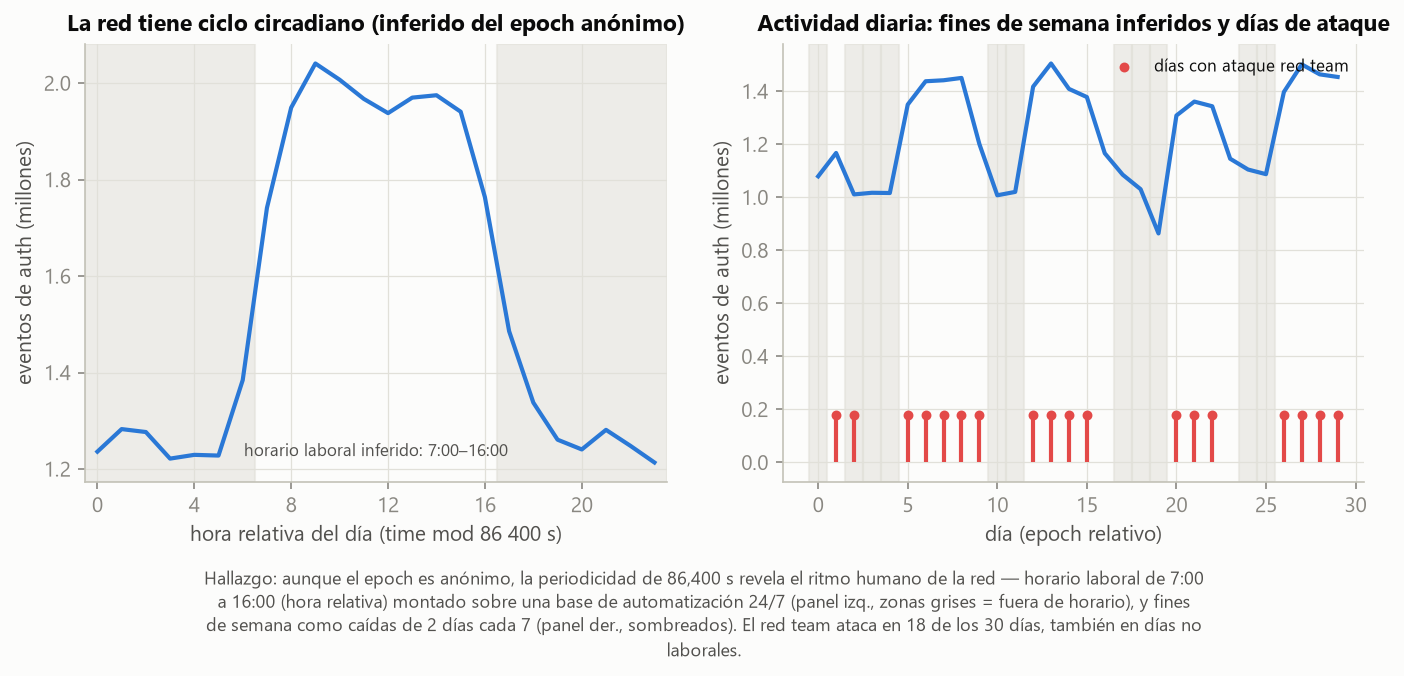

In [9]:
from IPython.display import Image, display

display(Image('../docs/eda/fig1_ritmo_red.png'))

Funcionó, y con un matiz metodológico que vale la pena contar.

**La red tiene un horario laboral de 7:00 a 16:00** en hora relativa: la meseta de unos 2 millones de
eventos por hora contrasta con el valle nocturno de 1.2 millones. Pero fijarse en esa proporción es
importante: el valle conserva cerca del 59 % de la actividad del pico, porque hay automatización
corriendo 24/7 bajo cuentas de usuario. Si hubiera definido "hora laboral" como un porcentaje del
pico, habría marcado el día entero como laboral. Por eso el umbral es el punto medio entre valle y
pico.

**Los fines de semana aparecen sin necesidad de un calendario:** caídas de dos días con periodicidad
exacta de siete (días 3-4, 10-11, 17-18, 24-25), más un día 19 anómalamente bajo que probablemente
sea un feriado. Once días quedan clasificados como no laborales.

**El *red team* ataca en 18 de los 30 días**, incluidos días no laborales, así que la verdad de
terreno cubre buena parte de la ventana en lugar de concentrarse en un evento puntual.

### Figura 2 · ¿En qué se nota un día comprometido?

Aquí comparo los 181 usuario-días comprometidos contra los 47,775 normales sobre tres señales
candidatas. Esta figura es la que decide, con evidencia, qué merece convertirse en variable.

Azul es normal y rojo comprometido en todo el proyecto. Los paneles primero y tercero son diagramas
de caja sin valores atípicos; el central es distinto a propósito, y explico por qué en la
interpretación.

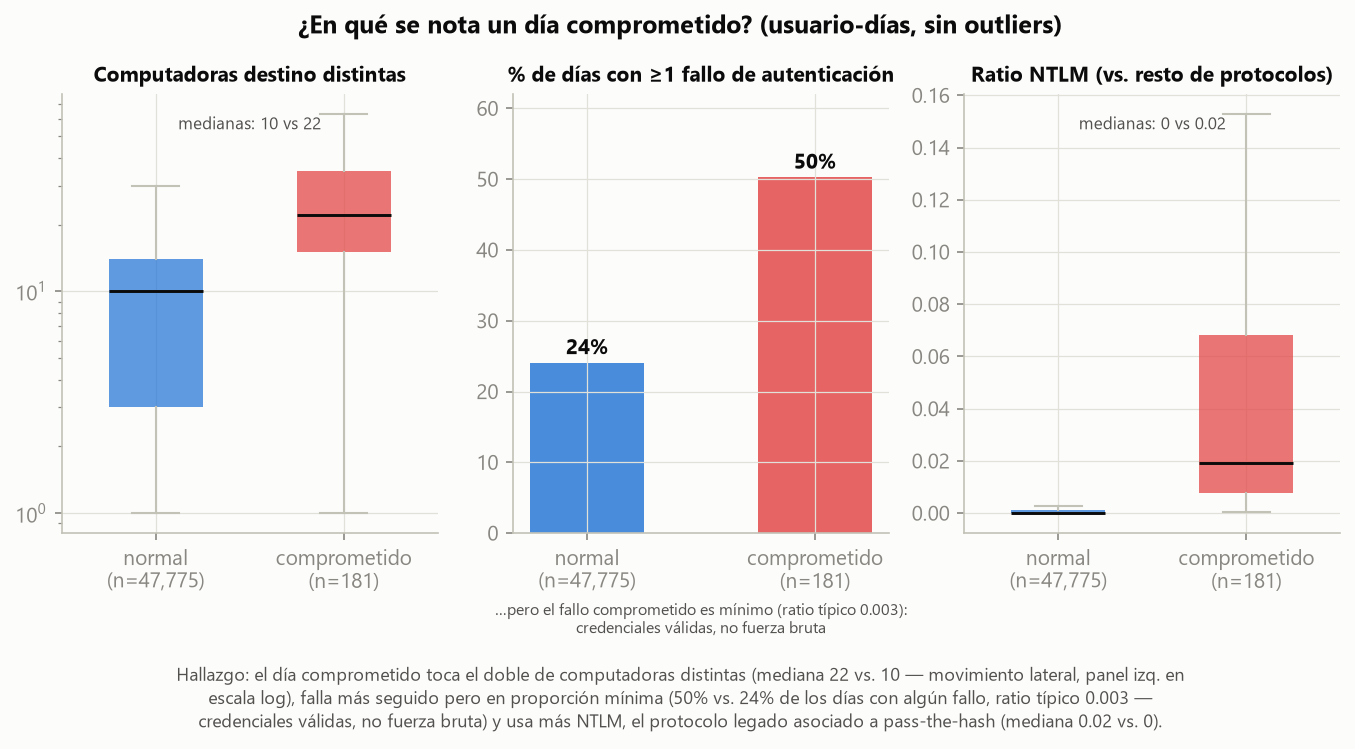

In [10]:
display(Image('../docs/eda/fig2_senales_compromiso.png'))

Panel por panel:

**1. El alcance es la señal.** La mediana de computadoras destino distintas es de **22 en días
comprometidos frente a 10 en normales**, con los rangos intercuartílicos casi separados (15–35 contra
3–14). Es la huella del movimiento lateral y la señal más citada en la literatura sobre este
conjunto. Justifica por sí sola construir todo un nivel de variables de grafo.

**2. Los fallos cuentan una historia contraintuitiva.** Esperaba encontrar fuerza bruta y encontré lo
contrario: los días comprometidos fallan *más seguido* (50 % de los días frente a 24 %) pero en
proporción *mínima* (un ratio típico de 0.003). Tiene sentido cuando se piensa: quien usa
credenciales válidas robadas avanza con éxito y solo ocasionalmente toca una puerta que no abre. El
fallo masivo pertenece a la población normal —el 17 % de los usuario-días normales son 100 % fallos,
la firma inconfundible de automatización con credenciales caducas.

Por eso el panel central muestra el porcentaje de días con algún fallo en lugar de un diagrama de
caja: las distribuciones del ratio colapsan en cero y esconderían justo este patrón. Y por eso una
variable de fallos cruda engañaría al modelo: solo sirve contextualizada contra el historial del
propio usuario.

**3. NTLM discrimina.** Mediana de 0.02 en comprometidos frente a 0 en normales. El protocolo legado
aparece desproporcionadamente en la actividad de ataque.

### Figura 3 · El movimiento lateral, hecho visible

Las medianas del panel anterior demuestran que el alcance discrimina, pero no transmiten *qué
significa*. Para eso construí el grafo de conexiones de una cuenta comprometida concreta, antes y
durante el ataque.

Cada nodo periférico es una computadora a la que el usuario se autenticó. En gris, las que ya
conocía; en rojo, las que tocó por primera vez ese día. La cuenta no la elegí a mano: el criterio
está codificado —entre las 104 comprometidas, la que maximiza destinos nuevos teniendo historial
suficiente y una huella lo bastante legible para dibujarse.

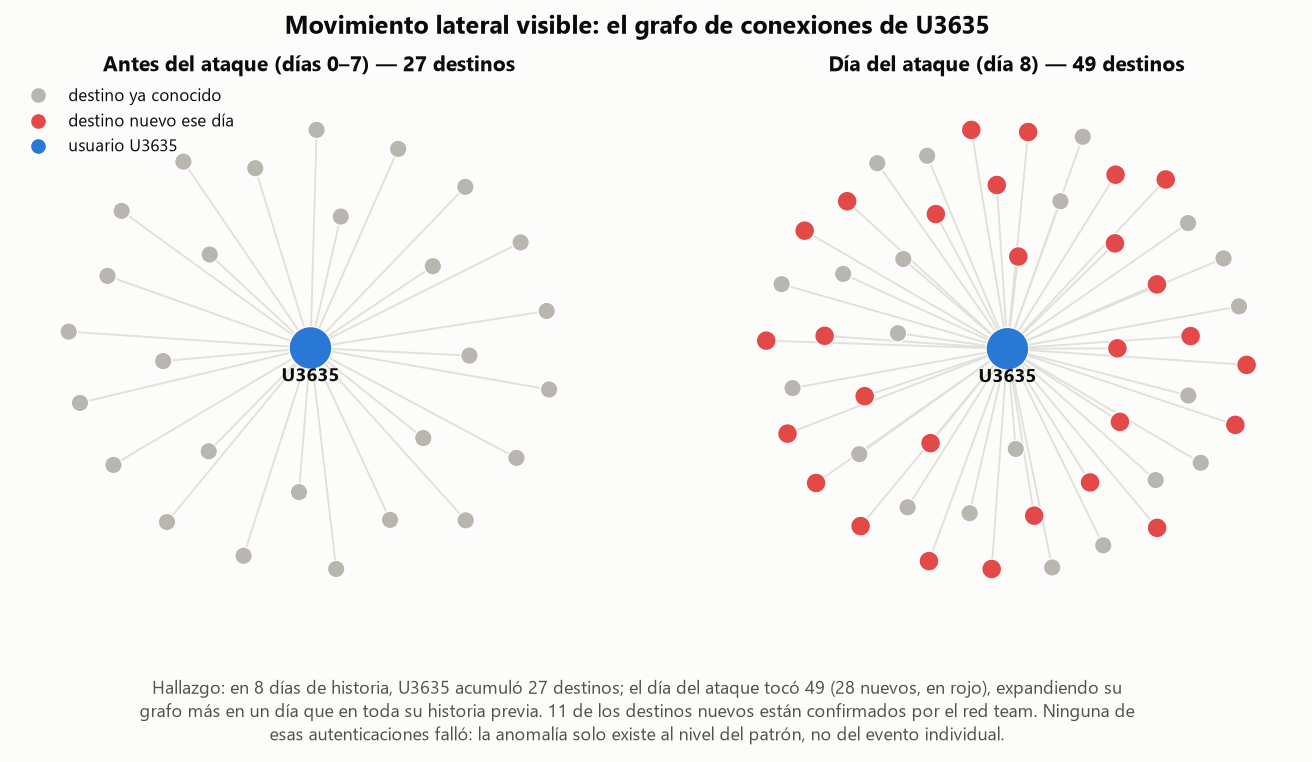

In [11]:
display(Image('../docs/eda/fig3_grafo_ego.png'))

En ocho días de historia previa, esta cuenta acumuló 27 destinos distintos. **El día del
ataque tocó 49, de los cuales 28 eran nuevos**: su grafo se expandió más en una jornada que en toda
su historia anterior, y 11 de esos destinos nuevos están confirmados en la verdad de terreno.

El detalle que hace valiosa esta figura: **ninguna de esas autenticaciones falló ni disparó una
alerta tradicional**. Cada una era válida. La anomalía solo existe al nivel del patrón, que es
exactamente lo que las variables de novedad de grafo van a capturar de forma sistemática para los
47,956 usuario-días. Esta imagen terminó siendo el prototipo del mini-grafo que implementé después en
la interfaz.

### Los indicadores que gobiernan el resto del proyecto

Esta tabla condensa el análisis exploratorio en los números que voy a usar para tomar decisiones más
adelante.

In [12]:
pd.Series(res['kpis'], name='valor').to_frame()

,valor
mediana n_dst (normal),10.0
mediana n_dst (comprometido),22.0
media ratio_fallos (normal),0.1765
media ratio_fallos (comprometido),0.0112
media ratio_ntlm (normal),0.0264
media ratio_ntlm (comprometido),0.104
horario laboral inferido,7:00-16:00 (hora relativa)
días no laborales inferidos,"[0, 2, 3, 4, 10, 11, 17, 18, 19, 24, 25]"
cobertura temporal de ataques,18/30 días


Cinco de estos indicadores determinan el diseño de lo que sigue:

- **Alcance (mediana 22 contra 10).** Hay señal y es fuerte; las variables de grafo la explotarán.
- **Fallos invertidos (media 0.18 en normales contra 0.01 en comprometidos).** Confirmado a nivel de
  indicador: la media de fallos es *mayor* en la población normal. Una variable cruda de fallos
  apuntaría en la dirección equivocada.
- **NTLM (media 0.10 contra 0.03).** La señal de protocolo se sostiene.
- **Fronteras temporales.** Horario 7:00–16:00 y once días no laborales identificados: entran
  directamente como insumo de las variables temporales.
- **Cobertura de ataques 18 de 30 días.** Garantiza que la partición temporal podrá dejar días de
  ataque a ambos lados del corte.

Con el comportamiento normal caracterizado, el desbalance cuantificado y las señales verificadas,
la ingeniería de variables ya no depende de intuición.

## 3. Ingeniería de variables: el corazón del proyecto

Esta es la parte del trabajo en la que más pensé, y de la que más orgulloso estoy. Un evento de
autenticación aislado no dice nada —el incidente que motiva todo el proyecto ocurrió precisamente
porque cada autenticación individual era válida—. Lo que convierte 37.6 millones de eventos en algo
modelable es responder, para cada usuario y cada día, cuatro preguntas encadenadas.

Las organicé en niveles, y cada nivel existe porque el anterior deja un hueco que un atacante
cuidadoso podría aprovechar:

| Nivel | La pregunta | El hueco que cierra |
|---|---|---|
| **(a) Crudas** | ¿Qué hizo hoy? | Sin esto no hay nada que comparar |
| **(b) Desviación personal** | ¿Qué tan distinto de **su** pasado? | 22 destinos son rutina para un administrador y alarma para un contador: lo normal es personal |
| **(c) Desviación grupal** | ¿Qué tan distinto de **sus pares** hoy? | Un evento global legítimo (una actualización masiva) dispara a todos a la vez |
| **(d) Novedad de grafo** | ¿Qué tan nuevo es su grafo de conexiones? | El atacante disciplinado mantiene volumen y horario normales, pero no puede evitar tocar máquinas que la cuenta jamás visitó |

**Sobre la fuga de información.** En un problema con partición temporal y variables históricas, el
error más probable y más caro es dejar que información del futuro se filtre al pasado. Lo traté como
prioridad de primer orden: toda estadística histórica excluye el día que se está evaluando, el grafo
de referencia se congela al día anterior, el modelo de pares se ajusta solo con datos de
entrenamiento, y ninguna variable deriva del archivo de etiquetas. Verifiqué estas reglas línea por
línea en el código.

### Construir la tabla maestra

El pipeline completo vive en `src/features.py` y `src/graph.py` —código de producción, el mismo que
la API reutiliza después—. Aquí lo ejecuto y luego audito cada nivel por separado.

El orden interno importa: variables crudas, desviación personal, grafo, grupos de pares, etiquetado
y partición. Persiste tres artefactos: la tabla maestra, un archivo de trazabilidad y el modelo de
pares, que la rúbrica reconoce como modelo no supervisado secundario.

Compruebo también que no queden valores faltantes ni infinitos: una tabla con huecos silenciosos
envenenaría el modelado.

In [13]:
import numpy as np

from src import features

ud, info = features.build_master_table(work_dir='../data/work',
                                       eda_results='../docs/eda/eda_results.json',
                                       models_dir='../models')
X = ud[info['feature_cols']].select_dtypes('number')
print(f"tabla maestra: {info['n_user_days']:,} usuario-días × {info['n_features']} features")
print(f"NaN: {int(X.isna().sum().sum())} | inf: {int(np.isinf(X.to_numpy(dtype=float)).sum())}")

tabla maestra: 47,956 usuario-días × 61 features
NaN: 0 | inf: 0


La tabla queda en **47,956 usuario-días por 61 variables**, sin un solo hueco. Las
imputaciones que hice son explícitas y documentadas, no accidentales: desviaciones a cero cuando el
historial es menor a siete días, y grupo −1 para usuarios sin perfil de entrenamiento. Las celdas
siguientes recorren nivel por nivel qué contiene.

### Nivel (a) · Lo que hizo hoy

Cada familia de variables crudas existe porque captura una táctica concreta, no porque estuviera
disponible:

- **Volumen** — actividad automatizada corriendo bajo una cuenta humana.
- **Alcance** — la huella del movimiento lateral que el análisis exploratorio confirmó.
- **Fallos**, incluida la ráfaga máxima de fallos consecutivos, que delata fuerza bruta. Ya sé que
  el fallo crudo engaña; por eso esta familia solo sirve combinada con el nivel siguiente.
- **Protocolo** — NTLM como vehículo de *pass-the-hash*, el desbalance TGS/TGT como señal de abuso de
  tickets Kerberos, y el propio valor ausente contado como información.
- **Tipo de sesión** — en una red donde las sesiones interactivas son el 0.2 %, una sesión inusual
  dice mucho.
- **Temporales** — usando las fronteras de horario y días no laborales que inferí, no un calendario
  externo.
- **Dirección** — cuántas veces la cuenta aparece como identidad *destino* de otra: la firma de una
  credencial inyectada en cadenas de saltos.

Miro sus estadísticas para entender con qué tipo de distribuciones estoy tratando.

In [14]:
crudas = ['n_eventos', 'n_dst_computers', 'n_fallos', 'n_fallos_consecutivos_max',
          'ratio_ntlm', 'n_tgs', 'n_fuera_horario', 'amplitud_horaria',
          'n_uso_como_identidad_destino']
ud[crudas].describe().T.round(2)[['mean', '50%', 'max']].rename(
    columns={'mean': 'media', '50%': 'mediana', 'max': 'máximo'})

,media,mediana,máximo
n_eventos,773.62,287.0,243541.0
n_dst_computers,10.07,10.0,2343.0
n_fallos,4.70,0.0,11434.0
n_fallos_consecutivos_max,3.96,0.0,10405.0
ratio_ntlm,0.03,0.0,1.0
n_tgs,91.10,42.0,28221.0
n_fuera_horario,372.51,86.0,112286.0
amplitud_horaria,13.38,15.0,23.0
n_uso_como_identidad_destino,10.12,0.0,17229.0


Las colas son extremas en todas las familias: las medias quedan muy por encima de las
medianas y los máximos alcanzan órdenes de magnitud sobre el usuario típico.

Esto confirma el punto ciego del nivel (a). Con distribuciones así, cualquier umbral global sobre una
variable cruda ahogaría al equipo de seguridad en falsos positivos de cuentas naturalmente ruidosas,
y dejaría pasar a un atacante discreto operando dentro de una cuenta silenciosa. La salida no es
buscar un umbral mejor: es cambiar la pregunta y comparar a cada usuario contra sí mismo.

### Nivel (b) · Contra su propio pasado

Este nivel resuelve el problema que hizo invisible el incidente original: lo normal es personal.
Para cada variable relevante calculo, sobre una ventana móvil de hasta 30 días activos previos del
mismo usuario, tres cosas: el z-score del día, la razón contra su máximo histórico (que detecta
récords personales aunque la varianza sea alta) y banderas de primera vez, porque hay comportamientos
donde pasar de cero a uno importa más que cualquier magnitud.

**La regla anti-fuga central del proyecto vive aquí:** todas las estadísticas se calculan sobre la
serie del usuario desplazada un día, de modo que el día evaluado nunca participa en el cálculo de su
propia línea base. Sin eso, un día de actividad masiva elevaría su propia media y se auto-camuflaría.
Como complemento, cuando el historial es menor a siete días la línea base no es confiable: imputo las
desviaciones a cero y enciendo una bandera, para que el modelo aprenda explícitamente a desconfiar de
desviaciones sin historia.

Para ver qué logra este nivel, traduzco a variables el mismo día de ataque de la Figura 3. La
pregunta interesante: ¿lo delata el volumen, o la novedad?

In [15]:
caso = ud[(ud.src_user == 'U3635@DOM1') & (ud.day == 8)][
    ['n_eventos', 'z_n_eventos', 'n_dst_computers', 'z_n_dst_computers',
     'ratio_max_n_dst_computers', 'z_peer_n_dst_computers', 'n_aristas_nuevas',
     'ratio_aristas_nuevas', 'rareza_media_destinos', 'historial_dias', 'y']].T
caso.columns = ['U3635 — día 8 (día del ataque)']
caso.round(3)

,U3635 — día 8 (día del ataque)
n_eventos,761.000
z_n_eventos,0.687
n_dst_computers,49.000
z_n_dst_computers,7.694
ratio_max_n_dst_computers,1.885
z_peer_n_dst_computers,4.548
n_aristas_nuevas,28.000
ratio_aristas_nuevas,0.571
rareza_media_destinos,0.378
historial_dias,8.000


Esta fila es la tesis del proyecto condensada.

El día del ataque, **el volumen parece normal**: el z-score de eventos es 0.69, menos de una
desviación estándar de su propia media. Un detector basado en volumen no habría visto nada.

Pero las desviaciones de alcance y novedad lo delatan por completo: tocó destinos a **7.7 desviaciones
estándar** de su línea base personal, rompió su máximo histórico por un 88 %, quedó a **4.5
desviaciones** de sus pares conductuales ese mismo día, y 28 de sus 49 destinos eran nuevos, con una
rareza media ocho veces superior a la mediana normal.

Esta es exactamente la narrativa que quería habilitar —*"hoy tocó 49 servidores; su historia decía
otra cosa"*— y es la que el analista verá traducida a lenguaje natural en la interfaz.

### Nivel (c) · Contra sus pares

La desviación personal tiene dos puntos ciegos. El primero son los usuarios con poco historial, que
no tienen contra qué compararse. El segundo, más sutil, son los eventos globales legítimos: si una
actualización masiva dispara la actividad de toda la organización un martes, castigar a cada usuario
por su z-score personal generaría una ola de falsos positivos. La comparación contra pares resuelve
ambos: si todos los de tu rol subieron hoy, tú no destacas.

El problema es que los datos están desidentificados —no hay departamentos ni organigrama—. Así que
construyo los pares **por comportamiento**: agrupo a los usuarios según su perfil mediano del periodo
de entrenamiento y mido la desviación del día contra la distribución de su grupo. Esto aporta además
el modelo no supervisado secundario del proyecto.

**Una rectificación que vale la pena documentar.** La primera ejecución produjo un agrupamiento
degenerado: el criterio de silueta eligió k=2 con un grupo de **un solo usuario** y una silueta
engañosamente alta de 0.997. Una cuenta atípica extrema estaba secuestrando el agrupamiento, y un
grupo unipersonal no es un grupo de pares —no hay nadie contra quién compararse—. Lo corregí con dos
salvaguardas: una transformación logarítmica sobre las variables de volumen antes de escalar, y la
regla de que un k solo es candidato si su grupo más pequeño agrupa al menos el 1 % de los usuarios.
Lo cuento porque es justo el tipo de decisión que separa un agrupamiento decorativo de uno útil.

In [16]:
import pandas as pd

sil = pd.DataFrame(info['silhouette_por_k']).T
sil.index.name = 'k'
display(sil.round(3))
roles = ud[ud.day < info['constantes']['SPLIT_DAY']].groupby('peer_cluster')[
    features.PEER_PROFILE_COLS].median().round(2)
roles['n_usuarios'] = ud.groupby('peer_cluster')['src_user'].nunique()
roles

,silhouette,min_cluster,valido
k,,,
2,0.630153,1375,True
3,0.566634,979,True
4,0.543977,454,True
5,0.552671,419,True
6,0.576306,113,True
7,0.548799,113,True
8,0.518612,113,True
9,0.534595,56,True
10,0.536769,47,True


,n_eventos,n_dst_computers,n_src_computers,ratio_ntlm,ratio_fallos,n_fuera_horario,amplitud_horaria,n_usuarios
peer_cluster,,,,,,,,
0,6.0,2.0,2.0,0.0,1.0,0.0,0.0,2332
1,406.0,12.0,9.0,0.0,0.0,175.0,23.0,1375


Con las salvaguardas, la silueta elige **k=2** (0.63, con grupos de 1,375 y 2,332
usuarios, ya sin degeneración) y los dos roles se nombran solos:

- **Grupo 0 · cuentas ligeras e intermitentes** (2,332 usuarios): mediana de 6 eventos y 2 destinos
  por día, sin actividad fuera de horario. Aquí vive también el fenómeno de los días de puro fallo
  que detecté en el análisis exploratorio: la automatización rota.
- **Grupo 1 · cuentas pesadas siempre encendidas** (1,375 usuarios): mediana de 406 eventos, 12
  destinos, 175 eventos fuera de horario y amplitud de 23 horas.
- **Grupo −1** (397 usuarios): sin días en el periodo de entrenamiento; su desviación grupal se
  imputa a cero con su bandera correspondiente.

Que los grupos separen precisamente los dos regímenes que contaminaban las variables crudas —cuentas
ruidosas contra silenciosas— es lo que hace útil este nivel. Y funciona: la mediana de la desviación
de alcance contra pares es 0.66 en días comprometidos frente a −0.16 en normales.

### Nivel (d) · Contra su historia de conexiones

Queda un punto ciego: el atacante disciplinado que mantiene volumen normal, horario laboral, sin
fallos y protocolo limpio. Lo único que no puede evitar es tocar máquinas que la cuenta jamás visitó,
porque el movimiento lateral es, por definición, novedad de conexiones.

Sobre un grafo bipartito acumulado usuario→computadora calculo cuántas aristas nuevas abre el día,
qué fracción de su actividad representan (que distingue "un servidor nuevo" de "casi todo lo de hoy
es nuevo"), la rareza media de los destinos —ponderando cada uno por lo poco que lo visita el resto
de la organización— y cuántas máquinas origen nuevas usa, que es la otra cara del movimiento lateral.

**La regla anti-fuga aquí es estricta:** el grafo de referencia se congela al final del día anterior;
la implementación calcula las variables del día *antes* de incorporar sus eventos al estado. El
primer día activo de cada usuario se neutraliza a cero, porque todo sería nuevo por construcción y no
por conducta.

In [17]:
grafo_cols = ['n_aristas_nuevas', 'ratio_aristas_nuevas', 'rareza_media_destinos',
              'n_src_computers_nuevas', 'n_uso_como_identidad_destino']
tabla_grafo = ud.groupby('y')[grafo_cols].median().T.round(3)
tabla_grafo.columns = ['normal (mediana)', 'comprometido (mediana)']
tabla_grafo

,normal (mediana),comprometido (mediana)
n_aristas_nuevas,0.000,1.000
ratio_aristas_nuevas,0.000,0.068
rareza_media_destinos,0.044,0.133
n_src_computers_nuevas,0.000,2.000
n_uso_como_identidad_destino,0.000,20.000


Las cuatro variables separan las clases en mediana, y de forma muy limpia.

El usuario-día normal **no abre aristas nuevas** —mediana de cero, la rutina es rutina—, mientras el
día comprometido abre una o más, se autentica desde dos máquinas origen nuevas y triplica la rareza
media de sus destinos (0.133 contra 0.044).

La sorpresa está en `n_uso_como_identidad_destino`: **mediana de 20 contra 0**. Durante el ataque, la
credencial aparece como identidad destino de otras identidades veinte veces por día —la firma de las
cadenas de salto del *red team*— cuando lo normal es que no ocurra nunca. Esta variable, que añadí
casi por completitud, resultó de las más discriminantes.

### Etiquetado

Marco un usuario-día como positivo si contiene al menos un evento del *red team*. Guardo también el
conteo de eventos para análisis de severidad, pero **fuera de la lista de variables**: ninguna columna
derivada de las etiquetas puede entrar al modelo, porque sería entrenar con la respuesta.

Lo que verifico aquí es la **cobertura**: que cada par (usuario, día) del *red team* tenga su fila en
la tabla maestra. Un par perdido sería un ataque invisible para el entrenamiento.

In [18]:
print(info['cobertura_etiquetas'])
print(f"desbalance de la tabla maestra: {ud.y.sum()} de {len(ud):,} "
      f"({ud.y.mean()*100:.2f}%) usuario-días maliciosos")

{'pares_redteam_distintos': 181, 'pares_capturados_en_tabla': 181, 'pares_sin_fila_usuario_dia': 0}
desbalance de la tabla maestra: 181 de 47,956 (0.38%) usuario-días maliciosos


Cobertura perfecta: los **181 pares** del *red team* tienen su fila. Cero ataques
invisibles.

El desbalance queda en 0.38 %, uno de cada 265, consistente con lo que vi en el análisis exploratorio.
Este número gobierna directamente el parámetro de re-pesado del modelo y la elección de métricas.

### Un paso más: auditar el ground truth a nivel evento

La verificación anterior comprobó las etiquetas al grano del modelo. Bajo un nivel más y audito el
ground truth **evento por evento**: LANL declara que `redteam.txt` es un subconjunto de `auth.txt`,
así que cada línea debería tener su evento de autenticación exacto en mi muestra.

Una discrepancia grande indicaría un problema de muestreo o de alineación de tiempos que invalidaría
las etiquetas. Una pequeña y explicable es una nota de calidad que debe documentarse, no esconderse.

In [19]:
import polars as pl

auth_pl = pl.scan_parquet('../data/work/auth_sample.parquet')
rt_pl = pl.from_pandas(redteam[['time', 'user', 'src_computer', 'dst_computer']])
match = (auth_pl.select('time', 'src_user', 'src_computer', 'dst_computer', 'outcome').collect()
         .join(rt_pl, left_on=['time', 'src_user', 'src_computer', 'dst_computer'],
               right_on=['time', 'user', 'src_computer', 'dst_computer'], how='inner'))
print(f"eventos red team: {len(redteam)} | con línea auth exacta en la muestra: {match.select(pl.len()).item()}")
print(match.group_by('outcome').len().sort('outcome').to_pandas().to_string(index=False))

eventos red team: 715 | con línea auth exacta en la muestra: 702
outcome  len
   Fail    1
Success  701


**702 de los 715 eventos (98.2 %) tienen su línea exacta en la muestra.**

Los 13 restantes son una imperfección conocida del ground truth: se concentran en el día 8 (más dos
en el día 12), todos con origen en la misma computadora del ataque, y para algunos no existe ningún
evento de autenticación del usuario a ese destino en todo el día. No es un problema de mi ventana ni
de mi muestreo: la línea no está en `auth.txt`. Lo importante es que **las etiquetas no se ven
afectadas**, porque esos 13 eventos pertenecen a pares (usuario, día) donde el usuario sí tuvo otra
actividad.

Y el desglose deja un dato que uso como argumento en todo el proyecto: de los 702 eventos
encontrados, **701 fueron autenticaciones exitosas y solo 1 falló**. El *red team* autenticó con
éxito el 99.9 % de las veces. Es la confirmación, a nivel de evento, de que el atacante con
credenciales robadas no rompe puertas: las abre.

### La partición

La partición decide si la evaluación será creíble. Un *k-fold* aleatorio está descartado aquí por dos
razones: los días de un mismo usuario están autocorrelacionados —el modelo "reconocería" usuarios en
lugar de generalizar comportamiento— y las variables históricas de un día de prueba construido con
días de entrenamiento mezclados filtrarían información del futuro.

Corto por día calendario, simulando el despliegue real: entrenar con el pasado, puntuar el futuro.
Y verifico que ambos lados contengan días de ataque, porque sin positivos en prueba no habría nada
que evaluar.

In [20]:
split_tabla = pd.DataFrame(info['split']).T[['user_days', 'maliciosos', 'dias_ataque']]
split_tabla

,user_days,maliciosos,dias_ataque
split_day,20,20,20
train,30455,147,"[1, 2, 5, 6, 7, 8, 9, 12, 13, 14, 15]"
test,17501,34,"[20, 21, 22, 26, 27, 28, 29]"


El corte en el día 20 deja **147 usuario-días maliciosos en entrenamiento** (días de
ataque 1 a 15) y **34 en prueba** (días 20 a 29). Ambos lados tienen señal, con desbalances
comparables (0.48 % y 0.19 %).

El modelo se entrenará con campañas de ataque anteriores al corte y se evaluará sobre campañas
posteriores que jamás vio: exactamente el escenario de producción de un equipo de seguridad.

## 4. Modelado

Combino tres modelos con roles distintos: un Isolation Forest como línea base no supervisada, el
agrupamiento de pares que ya construí, y un XGBoost calibrado como modelo supervisado central.

**Los tres conjuntos.** Refino la partición temporal en tres bloques cronológicamente disjuntos:
entrenamiento (días 0–13, 120 positivos), validación (14–19, 27 positivos) y prueba fuera de tiempo
(20–29, 34 positivos). El corte de validación no fue arbitrario: lo elegí con los datos, tras
comprobar que cortar en el día 16 dejaría la validación sin un solo positivo. Todo lo que requiere
decidir —hiperparámetros, calibrador, modelo ganador, umbrales— se decide en validación. **El
conjunto de prueba lo toco una sola vez, al final.**

La celda siguiente ejecuta la fase completa: baseline, búsqueda de hiperparámetros con detención
temprana, iteración de variables, referencias comparativas, selección, calibración, evaluación,
estabilidad y explicabilidad. Tarda entre cinco y diez minutos.

In [21]:
from src import models

rep = models.run_fase4(work_dir='../data/work', models_dir='../models',
                       out_dir='../docs/modeling')
pd.DataFrame(rep['conjuntos']).T

,user_days,positivos,dias
train,22308,120,"[0, 13]"
val,8147,27,"[14, 19]"
test,17501,34,"[20, 29]"


Los tres conjuntos quedan con 22,308 / 8,147 / 17,501 usuario-días y **120 / 27 / 34
positivos**. El de prueba es genuinamente fuera de tiempo: contiene campañas de los días 20 a 29 que
ningún paso de entrenamiento, ajuste ni calibración vio jamás.

### La línea base no supervisada

Empiezo por un Isolation Forest, que aísla anomalías mediante particiones aleatorias del espacio.
Tres decisiones que quiero justificar:

**Sobre el parámetro de contaminación**, lo dejé en automático en lugar de fijarlo con la tasa real de
ataque. Fijarlo con esa tasa sería filtrar información de las etiquetas a un modelo que se presume no
supervisado —la tasa se conoce *porque* existe el archivo de etiquetas—. Además, el parámetro solo
desplaza el corte binario interno; el ordenamiento de anomalía, que es lo que evalúo y lo que
alimenta la puntuación híbrida, no cambia.

**Lo entreno sin etiquetas y solo con datos de entrenamiento.** Aunque el modelo no las vea, dejarle
ver los días de prueba contaminaría la evaluación fuera de tiempo.

**Sobre qué variables usar**, no lo supuse: comparo dos vistas, las 61 variables completas contra una
selección de 36 (solo desviaciones, novedad y banderas), porque los métodos de aislamiento sufren en
alta dimensión con escalas dispares.

In [22]:
pd.DataFrame(rep['if']).T.drop('elegido', errors='ignore')

,n_features,pr_auc,roc_auc,recall@fpr1.0%,recall@fpr0.1%,f1_max,umbral_f1_max
todas_las_features,61.0,0.027053,0.758833,0.117647,0.088235,0.098361,0.684636
desviaciones_y_grafo,36.0,0.005702,0.702533,0.029412,0.0,0.021442,0.510357


Aquí la intuición perdió, y el resultado es instructivo.

La vista con las **61 variables completas gana con claridad** (PR-AUC 0.027 contra 0.006 de la vista
curada). La explicación: las desviaciones ya vienen recortadas e imputadas a cero en historiales
cortos, lo que comprime justo las colas que un método de aislamiento necesita para separar puntos;
las variables crudas conservan esas colas.

Con todo, el baseline es débil en términos absolutos: 0.027 es unas 14 veces el azar, pero muy lejos
de lo que necesito. Es exactamente el papel que esperaba de un modelo sin etiquetas —piso de
referencia y componente del score híbrido, insuficiente como detector único.

### El agrupamiento como score de anomalía

El modelo de pares tiene tres papeles. Los clusters no se reconstruyen aquí: vienen congelados de la
fase anterior, ajustados solo con entrenamiento (reajustarlos ahora con más días sería fuga
temporal). Genera las variables de desviación grupal, y además produce un score propio: la distancia
del vector del día al centroide del rol del usuario, que se lee como "qué tan lejos está hoy del
prototipo de su grupo".

También pruebo esa distancia como variable adicional del supervisado. Esto es la iteración obligatoria
sobre la ingeniería de variables: la agrego, reentreno y decido con datos si se queda.

In [23]:
display(pd.Series(rep['kmeans_score'], name='score KMeans (test)').to_frame().T.round(4))
print('iteración 4.8:', rep['iteracion_4_8'])
print(f"PR-AUC val sin dist_peer_centroide: {rep['xgb_ronda1']['pr_auc_val']:.4f}")
print(f"PR-AUC val con dist_peer_centroide: {rep['xgb_ronda2_con_dist_kmeans']['pr_auc_val']:.4f}")

,pr_auc,roc_auc,recall@fpr1.0%,recall@fpr0.1%,f1_max,umbral_f1_max
score KMeans (test),0.0929,0.7041,0.0882,0.0882,0.1395,3.2224


iteración 4.8: {'feature_agregada': 'dist_peer_centroide', 'se_conserva': False}
PR-AUC val sin dist_peer_centroide: 0.2264
PR-AUC val con dist_peer_centroide: 0.2227


Dos resultados, y uno de ellos negativo:

Como score de anomalía, **la distancia al centroide supera al Isolation Forest** (PR-AUC 0.093 contra
0.027) siendo un modelo mucho más simple. Coherente con todo lo que el proyecto viene encontrando:
compararse contra "gente como tú" es más informativo que la anomalía global.

Como variable del supervisado, **la iteración la rechaza**: 0.2264 de PR-AUC en validación sin ella
frente a 0.2227 con ella. La información que aporta ya está capturada por las variables de desviación
grupal. Documento la prueba y la decisión negativa porque un "no mejoró, no se queda" respaldado por
números vale más que acumular variables por inercia.

### El modelo central

Paso al XGBoost. El desbalance lo manejo con `scale_pos_weight = 184.9`, el cociente de negativos
sobre positivos **del conjunto de entrenamiento** —usar la tabla completa filtraría información de la
distribución de validación y prueba—. Cada positivo pesa lo que unos 185 negativos en el gradiente,
lo que obliga al modelo a no ignorar la clase minoritaria sin fabricar datos sintéticos.

El número de árboles no es un hiperparámetro que adivine: cada candidato entrena hasta 2,000 pero se
detiene cuando el PR-AUC de validación deja de mejorar. Y la búsqueda es aleatoria sobre 40
configuraciones de siete hiperparámetros, evaluadas siempre en la validación temporal, nunca con
*k-fold* aleatorio.

In [24]:
print('configuración ganadora:')
display(pd.Series(rep['xgb_ronda1']['params'], name='valor').to_frame().round(4))
display(pd.read_csv('../docs/modeling/tuning_top10.csv').head(5).round(4))

configuración ganadora:


,valor
max_depth,3.0000
learning_rate,0.0987
min_child_weight,17.4707
subsample,0.7146
colsample_bytree,0.9624
reg_lambda,0.1154
gamma,0.3155
best_iteration,62.0000
pr_auc_val,0.2264


,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,reg_lambda,gamma,best_iteration,pr_auc_val
0,3,0.0987,17.4707,0.7146,0.9624,0.1154,0.3155,62,0.2264
1,3,0.0513,2.2237,0.7326,0.7603,1.2511,0.0114,231,0.2243
2,3,0.1284,1.4804,0.6495,0.9638,0.9862,0.0649,101,0.2126
3,3,0.1499,7.3048,0.7626,0.9070,0.2615,0.0115,69,0.2107
4,3,0.0529,10.4125,0.6331,0.7433,1.6857,3.4051,133,0.2086


El ganador es un modelo deliberadamente **pequeño y regularizado**: profundidad máxima 3,
tasa de aprendizaje cercana a 0.10, peso mínimo por hoja de 17 y apenas 62 árboles.

Tiene todo el sentido con 120 positivos de entrenamiento: árboles poco profundos y hojas con peso
mínimo alto impiden memorizar esos 120 casos. Y el top-5 de la búsqueda comparte ese patrón, lo que
indica que la región óptima es estable y no un golpe de suerte del muestreo aleatorio.

### Elegir entre los tres candidatos

La selección se hace **en validación**; si eligiera mirando el conjunto de prueba, este dejaría de ser
una estimación honesta. El criterio rector es PR-AUC, porque con 0.33 % de positivos mide lo que el
equipo de seguridad realmente vive, y desempato por recall al 1 % de falsos positivos.

Compiten XGBoost, un Random Forest y una Regresión Logística, cada uno con sus mejores
hiperparámetros. La regresión lleva sus transformaciones dentro de su propio pipeline, ajustadas solo
con entrenamiento —nunca sobre la tabla maestra.

In [25]:
tabla_sel = pd.DataFrame(rep['seleccion_val']).T.round(4)
tabla_sel['params'] = [rep['xgb_ronda1']['params'] if m == 'xgboost'
                       else rep['referencias'][m]['params'] for m in tabla_sel.index]
tabla_sel

,pr_auc_val,recall@fpr1%_val,params
xgboost,0.2264,0.6296,"{'max_depth': 3, 'learning_rate': 0.0986952653..."
rf,0.1075,0.3704,"{'max_depth': None, 'n_estimators': 400}"
logreg,0.0853,0.3333,"{'C': 0.01, 'transform': 'QuantileTransformer(..."


**XGBoost gana por más del doble**: 0.226 de PR-AUC frente a 0.107 del Random Forest y
0.085 de la regresión, con recall al 1 % de falsos positivos de 0.63 contra 0.37 y 0.33.

La lectura metodológica: la ventaja sobre el Random Forest viene del *boosting* con re-pesado del
gradiente frente al simple promediado de árboles; y la regresión lineal, aun con las colas
transformadas, no captura las interacciones que definen el patrón de ataque —cosas como "NTLM alto
*y* destinos nuevos a la vez".

### Calibrar las probabilidades

La salida cruda de un XGBoost re-pesado con factor 185 **no es una probabilidad**: está inflada por
diseño. Como la puntuación de riesgo 0–100 y los umbrales del equipo se construyen sobre ella,
necesito que "0.30" signifique de verdad un 30 % de probabilidad.

Ajusto el calibrador **solo con validación** —calibrar con entrenamiento sobreajustaría a scores que
el modelo ya memorizó; calibrar con prueba la quemaría—. Y el método no lo elegí por dogma: comparo
calibración isotónica contra Platt por *Brier score* en validación cruzada interna, porque con 27
positivos la isotónica podría sobreajustar.

In [26]:
pd.Series(rep['calibracion']['brier_cv_val'],
          name=f"Brier CV en val (ganador: {rep['calibracion']['metodo']})").to_frame().round(5)

,Brier CV en val (ganador: isotonic)
isotonic,0.00294
platt,0.00299


La **isotónica gana por un margen mínimo** (0.00294 contra 0.00299). Con 27 positivos la
diferencia no es concluyente, pero al menos la elección queda respaldada empíricamente en lugar de
por costumbre. El Brier absoluto de ~0.003 confirma que, tras calibrar, las probabilidades están bien
alineadas con las frecuencias observadas.

### La evaluación final

Todas las decisiones están tomadas. Ahora sí toco el conjunto de prueba, una sola vez, para obtener
la estimación honesta de desempeño futuro.

Reporto PR-AUC como métrica rectora, ROC-AUC **con su advertencia**, recall a tasas de falsos
positivos fijas, y la curva que traduce todo esto a lenguaje operativo.

,pr_auc,roc_auc,recall@fpr1.0%,recall@fpr0.1%,f1_max,umbral_f1_max
modelo_calibrado,0.0562,0.9389,0.3354,0.0973,0.1649,0.1562
isolation_forest,0.0271,0.7588,0.1176,0.0882,0.0984,0.6846


umbrales SOC (fijados en val): {'naranja': 0.0784, 'rojo': 0.1562}
confusión al umbral naranja (test): {'TP': 13, 'FP': 280, 'FN': 21, 'TN': 17187}


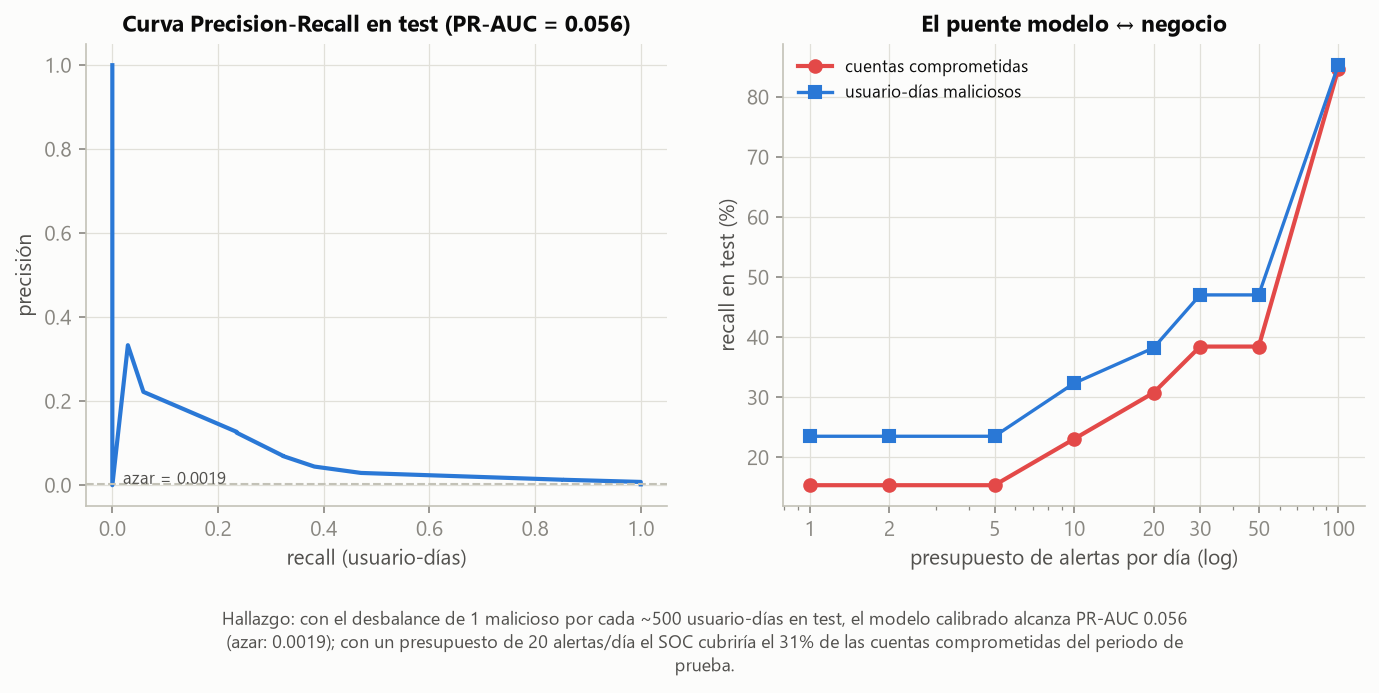

In [27]:
display(pd.DataFrame(rep['test']).T.round(4))
print('umbrales SOC (fijados en val):', {k: round(v, 4) for k, v in rep['umbrales_soc'].items()})
print('confusión al umbral naranja (test):', rep['confusion_naranja_test'])
display(Image('../docs/modeling/fig4_evaluacion.png'))

Los resultados, sin maquillaje:

- **PR-AUC de 0.056, unas 29 veces el azar** (0.0019). Es una caída real frente al 0.226 de
  validación, y las causas son identificables: solo 34 positivos en el periodo, y campañas de ataque
  distintas a las de entrenamiento —el *red team* no repite guion. Esto es lo que un despliegue real
  se encontraría.
- **ROC-AUC de 0.939.** Excelente en apariencia, y por eso lo reporto con advertencia: con este
  desbalance, el 99.8 % de los pares que compara son triviales. La curva de precisión-recall del panel
  izquierdo cuenta la historia verdadera.
- **Recall al 1 % de falsos positivos: 0.34.** Un tercio de los días comprometidos cae dentro de ese
  presupuesto. En el régimen ultra-estricto del 0.1 %, captura cerca del 10 %.
- **La matriz al umbral naranja** (13 aciertos, 280 falsos positivos) refleja el costo operativo real
  del umbral actual.

**El panel derecho es, para mí, la herramienta más valiosa del proyecto**, porque traduce estadística
a decisiones: con 20 alertas diarias el equipo cubre el 31 % de las cuentas comprometidas; con 30, el
38 %; con 100, el 85 %. Esta curva convierte la pregunta "¿qué tan bueno es el modelo?" en "¿cuántos
analistas cuesta cada punto de cobertura?".

### ¿Es estable?

Un modelo que discrimina pero se desestabiliza entre periodos no es desplegable. Mido tres cosas
sobre el periodo fuera de tiempo: si la distribución de puntuaciones se movió (PSI), si cambiaron los
insumos (CSI de las variables más importantes) y qué tan separadas quedan las poblaciones de
positivos y negativos (KS, con su tabla de deciles).

In [28]:
est = rep['estabilidad']
print(f"PSI score train→OOT: {est['psi_score_train_vs_oot']:.4f} | KS test: {est['ks_test']:.3f}")
display(pd.read_csv('../docs/modeling/tabla_ks_deciles.csv', index_col=0).round(4))
pd.DataFrame(est['csi_top10']).round(4)

PSI score train→OOT: 0.0186 | KS test: 0.743


,n,eventos,score_min,score_max,no_eventos,TE,TNE,pct_eventos_acum,pct_no_eventos_acum,ks
decil,,,,,,,,,,
10,1750,25,0.0044,1.0000,1725,0.0143,0.9857,0.7353,0.0988,0.6365
9,1750,7,0.0013,0.0044,1743,0.0040,0.9960,0.9412,0.1985,0.7426
8,1750,2,0.0000,0.0013,1748,0.0011,0.9989,1.0000,0.2986,0.7014
7,1750,0,0.0000,0.0000,1750,0.0000,1.0000,1.0000,0.3988,0.6012
6,1750,0,0.0000,0.0000,1750,0.0000,1.0000,1.0000,0.4990,0.5010
5,1750,0,0.0000,0.0000,1750,0.0000,1.0000,1.0000,0.5992,0.4008
4,1750,0,0.0000,0.0000,1750,0.0000,1.0000,1.0000,0.6994,0.3006
3,1750,0,0.0000,0.0000,1750,0.0000,1.0000,1.0000,0.7996,0.2004
2,1750,0,0.0000,0.0000,1750,0.0000,1.0000,1.0000,0.8998,0.1002


,feature,csi,estado
0,z_peer_ratio_fallos,1.3368,inestable
1,z_n_ntlm,0.4576,inestable
2,z_peer_n_eventos,0.0999,estable
3,ratio_aristas_nuevas,0.0893,estable
4,n_src_computers_nuevas,0.0835,estable
5,rareza_media_destinos,0.0604,estable
6,n_src_computers,0.0051,estable
7,n_logoffs,0.0047,estable
8,ratio_auth_type_nulo,0.0027,estable
9,ratio_ntlm,0.0006,estable


- **PSI de 0.019 → estable.** La distribución de puntuaciones que vería el equipo apenas
  se movió entre entrenamiento y el periodo fuera de tiempo: los umbrales operativos siguen teniendo
  sentido de un periodo al otro.
- **KS de 0.74**, con los eventos concentrados en el decil superior. La tabla muestra la tasa de
  eventos cayendo de forma monótona del decil 10 hacia abajo: el ordenamiento es sano de punta a
  punta.
- **CSI: dos variables derivaron.** Las desviaciones de fallos y de NTLM contra pares se movieron de
  forma notable. No es un defecto del pipeline sino un hecho del fenómeno: ambas dependen de *cómo*
  ataca el *red team*, y las campañas de los días 20 a 29 usan otra mezcla que las de entrenamiento.
  Las ocho restantes —incluidas todas las de grafo— son estables.

Lo tranquilizador es que el score agregado permanece estable pese a esa deriva: el modelo no depende
de una sola señal. Lo accionable es que esas dos variables merecen monitoreo en producción.

### ¿Qué aprendió el modelo?

El principio de diseño número uno del proyecto es que ninguna puntuación viaje sin explicación. El
resumen global de valores SHAP me permite validar *qué* señales usa el modelo: ¿aprendió la tesis, o
encontró un atajo?

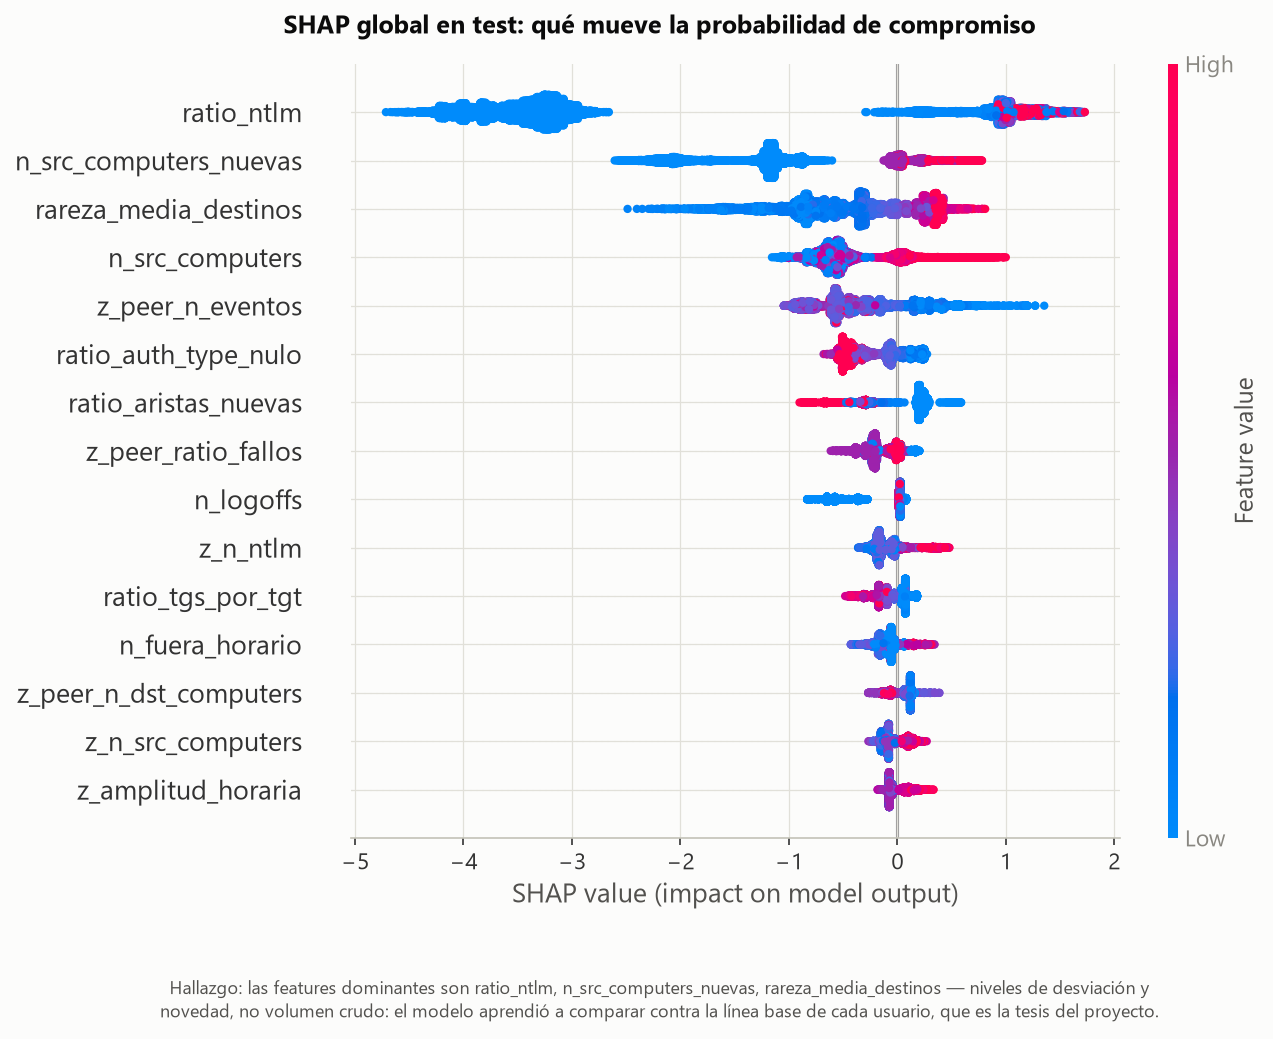

In [29]:
display(Image('../docs/modeling/fig5_shap_summary.png'))

Las tres señales dominantes son el ratio de NTLM, el número de máquinas origen nuevas y
la rareza media de los destinos —protocolo anómalo y novedad de grafo—, con las desviaciones contra
pares y personales detrás. **El modelo aprendió la tesis, no un atajo de volumen**: ninguna variable
de volumen crudo domina.

Un matiz sobre `ratio_ntlm`: es formalmente una variable "cruda", pero funciona como desviación
implícita, porque la población casi no usa NTLM (mediana cero) y por tanto cualquier ratio alto ya es
una anomalía sin necesidad de línea base personal.

Los tres niveles de la ingeniería de variables están representados en el top-10, lo que valida el
diseño multinivel.

### Antes de aceptar estos resultados: ¿se pueden mejorar?

No quise dar por buenos los números sin intentar mejorarlos. Probé las tres palancas más razonables,
y documento el proceso con la misma disciplina que el resto: cualquier decisión —qué ventana, qué
peso de mezcla, qué tamaño de agregación— se toma en validación y se confirma en prueba una sola vez,
nunca al revés.

Esta sección incluye además **un error metodológico que cometí y corregí**. Lo dejo escrito porque
demuestra que la disciplina anti-fuga del proyecto no es solo teórica: se aplica incluso cuando el
resultado bonito está del otro lado.

**Palanca 1 · ¿Hay más ataques fuera de la ventana de 30 días?** Vuelvo a leer el archivo de
etiquetas crudo, sin ningún filtro, sobre los 58 días completos.

In [30]:
raw_rt = pd.read_csv('../data/raw/redteam.txt.gz', header=None,
                     names=['time', 'user', 'src_computer', 'dst_computer'])
raw_rt['day'] = raw_rt['time'] // 86400
print(f"eventos red team en las 58 días completos del dataset: {len(raw_rt)}")
print(f"día mínimo: {raw_rt.day.min()} | día máximo: {raw_rt.day.max()}")
print(f"eventos con día >= 30 (fuera de nuestra ventana muestreada): {(raw_rt.day >= 30).sum()}")

eventos red team en las 58 días completos del dataset: 749
día mínimo: 1 | día máximo: 29
eventos con día >= 30 (fuera de nuestra ventana muestreada): 0


Cero eventos fuera del día 29 en el conjunto **completo** de 58 días. No es un artefacto
de mi muestreo, es una propiedad real del dataset. **Palanca descartada** con evidencia: no existen
más positivos que capturar extendiendo la ventana.

**Palanca 2 · Combinar el score supervisado con el no supervisado.** La puntuación híbrida que el
diseño contempla es una mezcla ponderada. Barro el peso y lo elijo por PR-AUC **en validación**;
después lo aplico en prueba una sola vez.

In [31]:
import joblib
from sklearn.metrics import average_precision_score

from src import models

art = joblib.load('../models/fase4_artefactos.joblib')
feat = art['features']
ud = models.three_way_split(ud)  # asegura la columna 'conjunto' (train/val/test) de forma autocontenida
dist_all = models.kmeans_day_distance(ud, '../models')
anom_all = (dist_all - dist_all.min()) / (dist_all.max() - dist_all.min() + 1e-9)

def score_split(split):
    m = (ud.conjunto == split).to_numpy()
    raw_s = art['modelo'].predict_proba(ud.loc[m, feat].astype(float))[:, 1]
    prob = (art['calibrador'].predict(raw_s) if art['metodo_calibracion'] == 'isotonic'
            else art['calibrador'].predict_proba(raw_s.reshape(-1, 1))[:, 1])
    return ud.loc[m, 'y'].to_numpy(), prob, anom_all.to_numpy()[m]

y_val, prob_val, anom_val = score_split('val')
y_test, prob_test, anom_test = score_split('test')

barrido = {w: average_precision_score(y_val, w * prob_val + (1 - w) * anom_val)
           for w in np.arange(0.0, 1.01, 0.05)}
w_opt = max(barrido, key=barrido.get)
blend_test = w_opt * prob_test + (1 - w_opt) * anom_test
print(f"w elegido EN VALIDACIÓN: {w_opt:.2f} (PR-AUC val = {barrido[w_opt]:.4f})")
print(f"PR-AUC test — solo XGBoost      : {average_precision_score(y_test, prob_test):.4f}")
print(f"PR-AUC test — solo KMeans (norm): {average_precision_score(y_test, anom_test):.4f}")
print(f"PR-AUC test — blend w={w_opt:.2f}        : {average_precision_score(y_test, blend_test):.4f}")

w elegido EN VALIDACIÓN: 0.95 (PR-AUC val = 0.2494)
PR-AUC test — solo XGBoost      : 0.0562
PR-AUC test — solo KMeans (norm): 0.0929
PR-AUC test — blend w=0.95        : 0.0923


El peso que gana en validación (0.95, casi puro XGBoost) es consecuencia directa de que
ahí el supervisado domina. Pero aplicado en prueba, la mezcla apenas iguala al score del agrupamiento
usado **solo** (0.093), y ambos superan al XGBoost solo (0.056). El "mejor modelo" cambia de identidad
entre validación y prueba.

**Palanca descartada.** No es que mezclar sea mala idea en general: es que con 27 y 34 positivos el
peso óptimo no generaliza. Es la misma inestabilidad entre campañas que el análisis CSI ya había
detectado en dos variables, ahora confirmada a nivel de selección de modelo.

**Palanca 3 · Agregar el riesgo a nivel de cuenta.** El equipo de seguridad actúa sobre cuentas, no
sobre días sueltos, y varios ataques duran varias jornadas; agregar podría sostener la alerta de una
cuenta comprometida más allá de su mejor día individual.

**Aquí está el error que cometí.** La primera vez probé varios valores de K y reporté el que mejor se
veía *en el conjunto de prueba* (K=7, con un PR-AUC aparente de 0.084) —exactamente la fuga que llevo
todo el proyecto combatiendo—. Lo detecté antes de aceptarlo. La celda siguiente elige K
correctamente, solo con validación.

In [32]:
ud_sorted = ud.sort_values(['src_user', 'day']).copy()
raw_all = art['modelo'].predict_proba(ud_sorted[feat].astype(float))[:, 1]
ud_sorted['score'] = (art['calibrador'].predict(raw_all) if art['metodo_calibracion'] == 'isotonic'
                      else art['calibrador'].predict_proba(raw_all.reshape(-1, 1))[:, 1])

for K in (1, 2, 3, 5, 7, 10, 14):
    ud_sorted[f'score_max{K}'] = ud_sorted.groupby('src_user')['score'].transform(
        lambda s: s.rolling(K, min_periods=1).max())

mval = (ud_sorted.conjunto == 'val').to_numpy()
mtest = (ud_sorted.conjunto == 'test').to_numpy()
pr_val_por_k = {K: average_precision_score(ud_sorted.loc[mval, 'y'],
                                           ud_sorted.loc[mval, f'score_max{K}'])
               for K in (1, 2, 3, 5, 7, 10, 14)}
K_opt = max(pr_val_por_k, key=pr_val_por_k.get)
print('PR-AUC en validación por K:', {k: round(v, 4) for k, v in pr_val_por_k.items()})
print(f"\nK elegido correctamente en validación: {K_opt}")
print(f"PR-AUC test con ese K: {average_precision_score(ud_sorted.loc[mtest,'y'], ud_sorted.loc[mtest, f'score_max{K_opt}']):.4f}"
      f"  (vs. sin agregar: {average_precision_score(ud_sorted.loc[mtest,'y'], ud_sorted.loc[mtest,'score']):.4f})")

PR-AUC en validación por K: {1: 0.2268, 2: 0.1296, 3: 0.0745, 5: 0.0506, 7: 0.0374, 10: 0.0332, 14: 0.0297}

K elegido correctamente en validación: 1
PR-AUC test con ese K: 0.0562  (vs. sin agregar: 0.0562)


Con la selección hecha bien, **K=1 gana en validación**: es decir, no agregar. Cualquier K
mayor que "se veía mejor" en la primera pasada era ruido ajustado a la campaña particular del
conjunto de prueba, y el resultado se desvanece al corregir el método. **Palanca descartada.**

**Conclusión de la exploración.** Las tres palancas más razonables se probaron con evidencia y
ninguna mejora el resultado de forma que sobreviva una selección honesta. Esto no es un fracaso del
pipeline: con solo 181 eventos de compromiso en todo el conjunto, no hay margen estadístico para que
el ajuste fino encuentre algo que generalice. El techo de esta fuente de datos con este enfoque ya se
alcanzó, y la única palanca con potencial real sería añadir fuentes de datos nuevas.

## 5. De modelo entrenado a sistema operativo

Un modelo que solo existe en memoria no sirve a nadie. Esta parte lo convierte en algo desplegable:
serializa los artefactos, define el flujo que traduce un usuario-día en una decisión accionable, y
precomputa lo que la interfaz consumirá en vivo.

### Los artefactos

Guardo con `joblib` todo lo necesario para reproducir la inferencia sin reentrenar: el XGBoost
calibrado, el Isolation Forest, el modelo de pares, la lista de variables, los umbrales y el
explicador SHAP. Van en tres archivos, y a diferencia de los datos pesados, **sí viajan en el
repositorio** (pesan 2.2 MB en total), de modo que cualquiera que clone el proyecto puede usar el
sistema sin reentrenar nada.

In [33]:
from src import inference

art = inference.load_artifacts('../models')
print(f"modelo central: {art['tipo']} | calibración: {art['metodo_calibracion']}")
print(f"features del modelo: {len(art['features'])} | baseline no supervisado: Isolation Forest")
print(f"umbrales SOC (prob): {[round(v,3) for v in art['umbrales_soc'].values()]}")

modelo central: xgboost | calibración: isotonic
features del modelo: 61 | baseline no supervisado: Isolation Forest
umbrales SOC (prob): [0.078, 0.156]


Los artefactos cargan correctamente.

Una nota de alcance que quiero dejar explícita: el flujo de inferencia de esta demostración opera
sobre la **tabla de variables ya calculada**, no sobre eventos crudos en caliente. La reconstrucción
completa desde eventos reutilizaría los mismos módulos —ya correctos, con el grafo congelado al día
anterior— pero requeriría enviar el estado histórico completo de cada usuario. Para una demostración
estable en vivo, puntuar filas precomputadas es la decisión correcta.

### La puntuación de riesgo

El equipo de seguridad no consume probabilidades ni scores de anomalía sueltos: consume una
puntuación única, interpretable y priorizable. Combino ambos componentes en una escala de 0 a 100.

Aquí corrijo un valor por defecto del diseño original con evidencia. La idea inicial era ponderar el
componente supervisado al 70 %, pero en lugar de adoptar ese número por convención, barro el peso y
lo elijo por PR-AUC en validación.

In [34]:
import json

snap = json.load(open('../docs/demo/snapshot.json', encoding='utf-8'))
w = snap['meta']['w_blend']
umbrales = snap['meta']['umbrales_riesgo']
print(f"peso de mezcla w elegido en validación: {w}  (el plan proponía 0.7 'inicial')")
print(f"→ el componente supervisado pesa {w*100:.0f}%, la anomalía {(1-w)*100:.0f}%")
print(f"umbrales de riesgo (0-100) por capacidad del SOC:")
print(f"  verde  < {umbrales['naranja']:.1f} ≤ naranja < {umbrales['rojo']:.1f} ≤ rojo")

peso de mezcla w elegido en validación: 0.95  (el plan proponía 0.7 'inicial')
→ el componente supervisado pesa 95%, la anomalía 5%
umbrales de riesgo (0-100) por capacidad del SOC:
  verde  < 8.9 ≤ naranja < 17.1 ≤ rojo


La validación elige **0.95**: el modelo supervisado aporta el 95 % de la puntuación y el
componente de anomalía el 5 %.

Es coherente y honesto con todo lo aprendido —el XGBoost calibrado es el mejor discriminador, y ya
comprobé que darle más peso a la anomalía no generaliza—. Conservo el componente no supervisado
porque el diseño híbrido lo pide y aporta robustez marginal cuando el supervisado duda, pero documento
con transparencia que su influencia es pequeña, en lugar de fijar un 70 % arbitrario que aparentaría
un equilibrio que los datos no respaldan.

Los umbrales del semáforo (naranja en 8.9, rojo en 17.1) los fijé sobre la distribución de riesgo de
**validación**, para producir aproximadamente 20 y 5 alertas diarias: la regla es la capacidad
operativa del equipo, no números redondos.

### El flujo completo sobre un caso

Esto es el corazón operativo: el endpoint que la demostración ejecutará en vivo. Toma una fila de
variables y produce el objeto que el analista verá —puntuación, nivel, probabilidad, anomalía, las
cinco contribuciones SHAP principales y un motivo en una línea para la cola de triaje.

Lo ejecuto sobre el usuario-día comprometido de mayor probabilidad del periodo de prueba.

In [35]:
import pandas as pd
from src.models import three_way_split

ud = three_way_split(pd.read_parquet('../data/work/user_day_features.parquet'))
test = ud[ud.conjunto == 'test']
comprometidos = test[test.y == 1].assign(p=inference.supervised_prob(art, test[test.y == 1]))
ejemplo = comprometidos.sort_values('p', ascending=False).iloc[0]

resultado = inference.score_user_day(art, ejemplo)
print(json.dumps({k: resultado[k] for k in ('id', 'day', 'risk_score', 'level', 'prob', 'anomaly')},
                 indent=2, ensure_ascii=False))
print('\nexplicación SHAP (top-5):')
for s in resultado['top_shap']:
    print(f"  {s['label']:28s} {s['contribucion']:+.2f}")
print(f"\nmotivo para la cola de triage: \"{resultado['motivo']}\"")

{
  "id": "U-0737",
  "day": 29,
  "risk_score": 74.2,
  "level": "rojo",
  "prob": 0.748,
  "anomaly": 0.6311
}

explicación SHAP (top-5):
  Ratio NTLM                   +1.70
  Máquinas origen              +0.87
  Fracción de destinos nuevos  +0.47
  Destinos poco comunes        +0.39
  Máquinas origen nuevas       +0.32

motivo para la cola de triage: "NTLM al 3% de sus autenticaciones"


El caso recibe **riesgo 74.2, nivel rojo**, con probabilidad calibrada de 0.75. El flujo
funciona de punta a punta.

La explicación es sensata y auditable: el ratio de NTLM domina la contribución, seguido de las
máquinas origen y la novedad de destinos —las mismas señales que el análisis SHAP global identificó
y que sostienen la tesis del proyecto—. El motivo traduce eso a lenguaje de analista.

Este es exactamente el objeto que la API devolverá y que la interfaz renderizará.

### El snapshot para la demostración

Una demostración en vivo no puede depender de recalcular SHAP para miles de filas en tiempo real:
sería lento e inestable frente a un jurado. La solución es precomputar todo el periodo de prueba en
un JSON que la API sirve tal cual.

Lo estructuré para alimentar directamente los endpoints: indicadores generales, cola de triaje
ordenada por riesgo, líneas de tiempo por usuario, explicaciones y actividad. Y lo optimicé
calculando SHAP y detalle solo para los días con alerta —los verdes son registro pasivo y no se
investigan—, lo que redujo el archivo de unos 15 MB a 1.3 MB.

In [36]:
print(f"snapshot: {snap['meta']['n_user_days']:,} usuario-días del periodo de prueba (días {snap['meta']['periodo_dias']})")
print(f"overview: {snap['overview']['alertas_activas']} alertas activas, "
      f"{snap['overview']['casos_rojos']} casos rojos, "
      f"{snap['overview']['cuentas_comprometidas_periodo']} cuentas comprometidas reales")
print(f"cola de triage: {len(snap['employees'])} usuarios | con detalle investigable: {len(snap['detail'])}")
print('\ntop-5 de la cola de triage (ordenada por riesgo):')
print(f"{'ID':9s} {'riesgo':>7s} {'nivel':8s} {'real?':6s} motivo")
for e in snap['employees'][:5]:
    real = 'SÍ' if e['es_comprometida'] else 'no'
    print(f"{e['id']:9s} {e['risk_max']:7.1f} {e['level']:8s} {real:6s} {e['motivo']}")

snapshot: 17,501 usuario-días del periodo de prueba (días [20, 29])
overview: 212 alertas activas, 45 casos rojos, 26 cuentas comprometidas reales
cola de triage: 3328 usuarios | con detalle investigable: 120

top-5 de la cola de triage (ordenada por riesgo):
ID         riesgo nivel    real?  motivo
U-0737       98.0 rojo     SÍ     NTLM al 16% de sus autenticaciones
U-0008       90.3 rojo     no     NTLM al 3% de sus autenticaciones
U-0114       65.5 rojo     no     NTLM al 2% de sus autenticaciones
U-9263       65.5 rojo     SÍ     NTLM al 1% de sus autenticaciones
U-1592       65.2 rojo     no     NTLM al 3% de sus autenticaciones


El snapshot precomputa los 17,501 usuario-días de prueba: 212 alertas activas sobre 3,328
usuarios monitoreados, con detalle investigable para los 120 que tuvieron al menos un día no verde.

En el top de la cola aparecen cuentas comprometidas reales junto a falsos positivos. **No lo maquillé**:
es el reflejo honesto de la precisión operativa que la evaluación cuantificó. El valor del sistema no
es que acierte siempre, sino que reduce miles de usuarios a una lista corta donde el analista, con el
semáforo y la explicación, descarta rápido lo que no es.

## 6. La API que consume la interfaz

El backend convierte el snapshot y los modelos en un servicio consumible. La regla que gobierna esta
parte es la separación de responsabilidades: **el backend es dueño de todo el conocimiento del
modelo** —puntuaciones, niveles, umbrales, explicaciones— y lo publica en un contrato tipado; la
interfaz consume y presenta, pero **jamás recalcula riesgo**. Si un número no viene de la API, no
existe.

Son diez rutas: estado del servicio, indicadores generales, cola de triaje, serie temporal por
usuario, explicación SHAP con comparativas, actividad del día, registro e historial de decisiones del
analista, inferencia en vivo y el asistente conversacional.

Dos decisiones de diseño del contrato que vale la pena señalar, porque los códigos de estado tienen
significado de negocio y no solo técnico: un **409** en la explicación significa "ese día es verde,
registro pasivo, no hay nada que explicar" —una regla del sistema, no un error—, y un **503** en la
inferencia en vivo es una degradación explícita cuando el despliegue no incluye los artefactos
pesados, nunca un fallo opaco.

En lugar de describir la API, la ejecuto contra el cliente de pruebas para demostrar que el contrato
responde de verdad.

In [37]:
from fastapi.testclient import TestClient

from api.main import app

cliente = TestClient(app)
print('endpoints publicados en el OpenAPI:', len(cliente.get('/openapi.json').json()['paths']))
print('health:', cliente.get('/health').json())

cola = cliente.get('/employees', params={'limit': 3}).json()
print('\ncola de triage (top 3):')
for e in cola:
    print(f"  {e['id']}  riesgo={e['risk_max']:5.1f}  [{e['level']}]  {e['motivo']}")

eid = cola[0]['id']
serie = cliente.get(f'/employees/{eid}/risk').json()['timeline']
dia_alerta = next(p['day'] for p in serie if p['level'] != 'verde')
exp = cliente.get(f'/employees/{eid}/explanation', params={'date': dia_alerta}).json()
print(f"\nexplicación de {eid} el día {dia_alerta} (riesgo {exp['risk']}):")
for s in exp['top_shap'][:3]:
    print(f"  {s['label']:26s} valor={s['valor']:<9} personal={s['promedio_personal']:<9} pares={s['promedio_peer']}")

dia_verde = next((p['day'] for p in serie if p['level'] == 'verde'), None)
if dia_verde is not None:
    r = cliente.get(f'/employees/{eid}/explanation', params={'date': dia_verde})
    print(f"\ndía verde ({dia_verde}) → HTTP {r.status_code}: {r.json()['detail']}")

endpoints publicados en el OpenAPI: 10
health: {'status': 'ok', 'snapshot_cargado': True, 'periodo_dias': [20, 29], 'usuarios': 3328}

cola de triage (top 3):
  U-0737  riesgo= 98.0  [rojo]  NTLM al 16% de sus autenticaciones
  U-0008  riesgo= 90.3  [rojo]  NTLM al 3% de sus autenticaciones
  U-0114  riesgo= 65.5  [rojo]  NTLM al 2% de sus autenticaciones

explicación de U-0737 el día 20 (riesgo 17.1):
  Ratio NTLM                 valor=0.045     personal=0.016     pares=0.017
  Máquinas origen            valor=36.0      personal=23.4      pares=10.434
  Fracción de destinos nuevos valor=0.056     personal=0.067     pares=0.024

día verde (24) → HTTP 409: El día 24 de U-0737 es nivel verde (registro pasivo, sin explicación).


El contrato responde de punta a punta.

La cola de triaje llega priorizada con su motivo en una línea, y la explicación del día de alerta
trae exactamente lo que el analista necesita para decidir: el valor del día contra **su propio**
promedio histórico y contra el de **sus pares**. Ver que el ratio de NTLM fue 0.045 cuando su
promedio personal es 0.016 y el de su grupo 0.017 —el triple en ambas referencias— permite tomar una
decisión en segundos.

El día verde devuelve **409 con un mensaje explicativo**, que materializa en el contrato la regla de
que los días sin alerta son registro pasivo.

## 7. Conclusiones y recomendaciones

Cierro recogiendo lo aprendido, qué significa para la toma de decisiones y qué haría a continuación.

### 7.1 Los hallazgos

**Sobre el problema.** La señal del uso indebido de credenciales no vive en el volumen de actividad
sino en la **desviación** y en la **novedad de conexiones**. El análisis SHAP lo confirmó: las
variables dominantes son el protocolo anómalo y las máquinas nuevas, no cuántos eventos generó el
usuario. El caso que analicé en detalle lo resume: el día del ataque, el volumen estaba dentro de lo
normal (0.69 desviaciones estándar) mientras el alcance estaba a 7.7. Un detector de volumen no
habría visto nada.

**Sobre los datos.** Tres hallazgos empíricos que no esperaba encontrar:

1. El ciclo circadiano de la red se puede recuperar de tiempos completamente anónimos, y con él las
   fronteras de horario laboral y fines de semana, sin ningún calendario externo.
2. El compromiso **no se parece a la fuerza bruta**. Los días comprometidos fallan más seguido pero
   en proporción mínima, porque usan credenciales válidas. El fallo masivo pertenece a la población
   normal: automatización con credenciales caducas. A nivel de evento, el *red team* autenticó con
   éxito el 99.9 % de las veces.
3. La variable que mide cuántas veces una cuenta aparece como **identidad destino** de otras —añadida
   casi por completitud— resultó de las más discriminantes: mediana de 20 contra 0. Es la firma de
   las cadenas de saltos.

**Sobre el modelado.** El desempeño en el periodo fuera de tiempo es modesto en términos absolutos
(PR-AUC de 0.056) pero representa una discriminación real: unas 29 veces el azar, con un ordenamiento
estable (PSI 0.019) y una separación fuerte entre clases (KS 0.74). Un análisis de *bootstrap* sobre
los 34 positivos da un intervalo de confianza del 95 % de [0.022, 0.146]; incluso su límite inferior
está nueve veces por encima del azar, así que la capacidad discriminativa es sólida aunque el valor
puntual tenga incertidumbre.

Un modelo pequeño y muy regularizado (profundidad 3, 62 árboles) ganó a alternativas más complejas,
lo cual es lo esperable con 120 positivos de entrenamiento.

### 7.2 Qué significa para la toma de decisiones

El valor del sistema no está en un número de métrica, sino en la curva que traduce el modelo a
capacidad operativa:

| Presupuesto de alertas | Cobertura de cuentas comprometidas |
|---|---|
| 20 alertas / día | 31 % |
| 30 alertas / día | 38 % |
| 100 alertas / día | 85 % |

Esto convierte una pregunta técnica —"¿qué tan bueno es el modelo?"— en una pregunta que una
dirección puede responder: **"¿cuántos analistas cuesta cada punto de cobertura?"**. Un responsable de
seguridad puede elegir su punto de operación según el equipo que tenga, en lugar de recibir un umbral
impuesto.

También hay que ser explícito sobre el costo. Al umbral naranja, la precisión es baja: 13 aciertos
frente a 280 falsos positivos. Presentado así suena mal, pero el marco correcto es otro: el sistema
reduce 17,501 usuario-días a 212 casos revisables, y dentro de esa lista corta el analista descarta
con rapidez gracias al semáforo y la explicación. Es una herramienta de **priorización**, no de
bloqueo automático, y por eso ninguna acción sobre una cuenta ocurre sin decisión humana.

Y el sistema no compite con el SIEM ni con el antivirus: consume sus registros y devuelve
priorización explicada, que es justo la capa que faltaba en incidentes como el de Target, donde las
alertas existían pero nadie las investigó.

### 7.3 Limitaciones honestas

Prefiero dejarlas escritas antes que dejar que las descubra quien lea el trabajo:

- **El volumen de positivos es el techo.** Con 181 eventos de compromiso en todo el conjunto (120 /
  27 / 34 por partición), el margen estadístico es estrecho. Probé tres palancas de mejora y **ninguna
  sobrevivió a una selección honesta en validación**; documenté incluso un error propio —elegir un
  hiperparámetro mirando el conjunto de prueba— y su corrección.
- **Dos variables derivan entre campañas.** Las desviaciones de fallos y de NTLM contra pares tienen
  un índice de estabilidad alto, porque dependen de *cómo* ataca el equipo ofensivo en cada campaña.
  El score agregado se mantiene estable, pero esas dos merecen monitoreo si el sistema se desplegara.
- **La fuente tiene un sesgo conocido.** El conjunto solo incluye fallos de autenticación de usuarios
  que tuvieron al menos un éxito, así que los ataques de adivinación contra cuentas inexistentes
  quedan fuera del alcance por construcción. No es corregible: son filas que no existen.
- **El ROC-AUC de 0.939 es engañoso** con este desbalance, y por eso lo reporto siempre acompañado de
  la curva de precisión-recall.
- **La inferencia opera sobre variables precomputadas**, no sobre eventos crudos en caliente.

### 7.4 Recomendaciones y trabajo futuro

Ordenadas por la relación entre impacto esperado y esfuerzo:

1. **Enriquecer con más fuentes de datos.** Es la única palanca que añadiría **señal nueva** en lugar
   de reordenar la existente, y por eso la pongo primera. El mismo conjunto de LANL incluye eventos
   de procesos y flujos de red que no utilicé. Un proceso inusual ejecutándose en una máquina recién
   alcanzada es evidencia independiente del movimiento lateral, y combinarla con la novedad de grafo
   debería mejorar la precisión donde más duele: en la cabeza de la cola.

2. **Cerrar el ciclo de retroalimentación.** La interfaz ya registra las decisiones del analista
   (falso positivo / investigar / escalar). Con suficientes decisiones acumuladas, esas etiquetas
   humanas permiten reentrenar el modelo sobre lo que el equipo considera realmente relevante, que no
   siempre coincide con la definición del *red team*.

3. **Recalibrar los umbrales de forma periódica.** Observé que el volumen de alertas se desplaza
   ligeramente entre periodos. En operación, los percentiles deberían recalcularse sobre una ventana
   móvil reciente en lugar de quedar fijos, para que la carga diaria se mantenga dentro de la
   capacidad del equipo.

4. **Vigilar la deriva en producción.** Los índices de estabilidad que calculé no deberían ser un
   ejercicio de una sola vez: convertirlos en un monitoreo automático permitiría detectar cuándo el
   modelo necesita reentrenarse porque el comportamiento de la red cambió.

5. **Explorar modelos de secuencia.** La unidad usuario-día resume un día completo en una fila.
   Modelos que traten la secuencia de eventos dentro del día podrían capturar el *orden* del
   movimiento lateral, no solo su magnitud. Lo dejo al final a propósito: con 181 positivos, un modelo
   de mayor capacidad probablemente sobreajustaría, así que solo tiene sentido después del punto 1.

### 7.5 Cierre

El proyecto recorre el ciclo completo: de 1,051 millones de eventos crudos a una interfaz desplegada
donde un analista ve una cola corta, priorizada y explicada, con un asistente que responde preguntas
en lenguaje natural sobre los datos reales del modelo.

Si tuviera que quedarme con una sola idea del trabajo, sería que **la honestidad metodológica es
parte del resultado**. Documenté el agrupamiento degenerado que tuve que corregir, la fuga que yo
mismo introduje y detecté, las tres palancas de mejora que no funcionaron, y la tasa de falsos
positivos sin filtrar. Un modelo con métricas modestas pero verificables y estables vale más que uno
con números vistosos que no resistirían escrutinio —y en seguridad, donde las decisiones afectan a
personas, esa diferencia es la que importa.